In [1]:
#import required libraries

import pandas as pd
import numpy as np
import time
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (classification_report, f1_score, accuracy_score, confusion_matrix)

import seaborn as sbn
import matplotlib.pyplot as plt

#import pytorch since tensorflow is not supporting in python 3.14
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin

torch.manual_seed(42)

import shap

print("All libraries imported")

All libraries imported


In [2]:
#configuration of paths of preprocessed train and test sets

CICIoT_Train= r"C:\Users\NARASIMHA N\OneDrive\Desktop\comparative_analysis_arp_spoofing\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\CICIoT2023 Dataset\Test and Train Sets\CICIoT2023_train.csv"
CICIoT_Test= r"C:\Users\NARASIMHA N\OneDrive\Desktop\comparative_analysis_arp_spoofing\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\CICIoT2023 Dataset\Test and Train Sets\CICIoT2023_test.csv"

IoT_NID_Train= r"C:\Users\NARASIMHA N\OneDrive\Desktop\comparative_analysis_arp_spoofing\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\IoT Network Intrusion Dataset\Training and Testing CSVs\IoT_NID_train.csv"
IoT_NID_Test= r"C:\Users\NARASIMHA N\OneDrive\Desktop\comparative_analysis_arp_spoofing\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\IoT Network Intrusion Dataset\Training and Testing CSVs\IoT_NID_test.csv"

UQIoT_Train= r"C:\Users\NARASIMHA N\OneDrive\Desktop\comparative_analysis_arp_spoofing\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\UQ-IoT Dataset\Testing and Training CSVs\UQ-IoT_train.csv"
UQIoT_Test= r"C:\Users\NARASIMHA N\OneDrive\Desktop\comparative_analysis_arp_spoofing\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\UQ-IoT Dataset\Testing and Training CSVs\UQ-IoT_test.csv"

Output_Dir= r"C:\Users\NARASIMHA N\OneDrive\Desktop\comparative_analysis_arp_spoofing\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\Cross-Dataset Evaluation\Outputs"

Label_columns= "label"

os.makedirs(Output_Dir, exist_ok=True)
print("All paths are assigned.")

All paths are assigned.


In [3]:
#loading all test antrain CSVs into dataframes

ciciot_train=pd.read_csv(CICIoT_Train)
ciciot_test=pd.read_csv(CICIoT_Test)

iot_nid_train=pd.read_csv(IoT_NID_Train)
iot_nid_test=pd.read_csv(IoT_NID_Test)

uqiot_train=pd.read_csv(UQIoT_Train)
uqiot_test=pd.read_csv(UQIoT_Test)

print("Loaded shapes: \n")
print(f"CICIoT2023 Dataset --> Train: {ciciot_train.shape}, Test: {ciciot_test.shape}")
print(f"IoT_NID Dataset    --> Train: {iot_nid_train.shape}, Test: {iot_nid_test.shape}")
print(f"UQIoT Dataset      --> Train: {uqiot_train.shape}, Test: {uqiot_test.shape}")

Loaded shapes: 

CICIoT2023 Dataset --> Train: (32000, 104), Test: (8000, 104)
IoT_NID Dataset    --> Train: (32000, 104), Test: (8000, 104)
UQIoT Dataset      --> Train: (24482, 104), Test: (7061, 104)


In [4]:
#confomation of all datasets contains same set of features

ciciot_features= [feature for feature in ciciot_train.columns if feature != Label_columns]
iot_nid_features= [feature for feature in iot_nid_train.columns if feature != Label_columns]
uqiot_features= [feature for feature in uqiot_train.columns if feature != Label_columns]

match= (ciciot_features==iot_nid_features==uqiot_features)
if(match):
    print("All datasets contain same set of features")
    print(f"Number of features: {len(uqiot_features)}")
else:
    print("Datasets contains different feature set. Therefore, cross-dataset evaluation is not possible.")



All datasets contain same set of features
Number of features: 103


In [5]:
#define models as we defined earlier for same dataset training and testing

#DNN Architecture

class TorchDNN(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network=nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

class DNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=50, batch_size=256, lr=0.001, patience=5, random_state=42):
        self.epochs=epochs
        self.batch_size=batch_size
        self.lr=lr
        self.patience=patience
        self.random_state=random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)

        X=np.asarray(X, dtype=np.float32)
        y=np.asarray(y, dtype=np.float32).reshape(-1,1)

        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.1, random_state=self.random_state, stratify=y)

        self.model_= TorchDNN(X.shape[1])
        optimizer=torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        loss_function=nn.BCELoss()

        X_tr_t = torch.tensor(X_tr)
        y_tr_t = torch.tensor(y_tr)
        X_val_t = torch.tensor(X_val)
        y_val_t = torch.tensor(y_val)

        best_val_loss = float('inf')
        best_state=None
        epoch_no_improve=0
        n_samples=X_tr_t.shape[0]

        for epoch in range(self.epochs):
            self.model_.train()
            permutation=torch.randperm(n_samples)

            for i in range (0, n_samples, self.batch_size):
                idx=permutation[i : i + self.batch_size]
                batch_X, batch_y = X_tr_t[idx], y_tr_t[idx]

                optimizer.zero_grad()
                outputs=self.model_(batch_X)
                loss=loss_function(outputs, batch_y)
                loss.backward()
                optimizer.step()

            self.model_.eval()
            with torch.no_grad():
                val_loss=loss_function(self.model_(X_val_t), y_val_t).item()

            if val_loss < best_val_loss:
                best_val_loss=val_loss
                best_state={k: v.clone() for k, v in self.model_.state_dict().items()}
                epoch_no_improve=0
            else:
                epoch_no_improve=epoch_no_improve+1
                if epoch_no_improve >= self.patience:
                    break

        if best_state is not None:
            self.model_.load_state_dict(best_state)

        self.classes_=np.array([0,1])
        return self

    def predict_proba(self,X):
        X=np.asarray(X, dtype=np.float32)
        self.model_.eval()
        with torch.no_grad():
            probs=self.model_(torch.tensor(X)).numpy().flatten()
        return np.column_stack([1-probs, probs])

    def predict(self,X):
        probs=self.predict_proba(X)[:,1]
        return (probs>=0.5).astype(int)

def get_models():
    #this function returns the fresh dictionary of untrained models
    #A new dictionary will create each time so model from one training run do not affect to other

    models={
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
        "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        "SVM": SVC(kernel='rbf', random_state=42, probability=True),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
        "DNN": DNNClassifier(epochs=50, batch_size=256, lr=0.001, patience=5, random_state=42)
    }
    return models

print("Models successfully defined and the defined models are: \n")
print(list(get_models().keys()))

Models successfully defined and the defined models are: 

['Decision Tree', 'Random Forest', 'KNN', 'SVM', 'Logistic Regression', 'XGBoost', 'DNN']


In [6]:
#Defing helper function to train on one dataset and test on another dataset

def run_cross_dataset(train_df, test_df, train_name, test_name, feature_columns):
    print(f"Train: {train_name} --> Test: {test_name}\n")

    X_train= train_df[feature_columns].values
    y_train=train_df[Label_columns].values

    X_test=test_df[feature_columns].values
    y_test=test_df[Label_columns].values

    print(f"Training size: {X_train.shape[0]} rows")
    print(f"Attack: {(y_train==1).sum()}")
    print(f"Benign: {(y_train==0).sum()}")
    print(f"\n Testing size: {X_test.shape[0]} rows")
    print(f"Attack: {(y_test==1).sum()}")
    print(f"Benign: {(y_test==0).sum()}")


    # Apply Fit scalar on training data only, then transform both sets
    #fitting on testing data would be data leakage, i.e., the model would see information about test distribution before predicting

    scaler=StandardScaler()
    X_train=scaler.fit_transform(X_train)
    X_test=scaler.transform(X_test)

    X_train_df=pd.DataFrame(X_train, columns=feature_columns)
    X_test_df=pd.DataFrame(X_test, columns=feature_columns)

    results=[]
    models=get_models()

    for model_name , model in models.items():
        print(f"\n [{model_name}]")

        #train the model and record the training time
        train_start=time.time()
        model.fit(X_train, y_train)
        train_end=time.time()
        train_time=train_end-train_start

        #predict on the other test set and calculate the prediction time

        test_start=time.time()
        y_pred=model.predict(X_test)
        test_end=time.time()
        test_time=test_end-test_start

        #calculate metrics
        acc=accuracy_score(y_test, y_pred)
        f1=f1_score(y_test, y_pred, average='weighted')
        f1_attack=f1_score(y_test, y_pred, pos_label=1, average='binary')
        f1_benign=f1_score(y_test, y_pred, pos_label=0, average='binary')

        print(f"Accuracy: {acc}")
        print(f"F1 Score Weighted: {f1}")
        print(f"F1 Score Attack: {f1_attack}")
        print(f"F1 Score Benign: {f1_benign}")
        print(f"Training time: {train_time} sec")
        print(f"Testing time: {test_time} sec")

        results.append({
            "Train Dataset": train_name,
            "Test Dataset": test_name,
            "Model": model_name,
            "Accuracy": acc,
            "F1 Weighted": f1,
            "F1 Attack": f1_attack,
            "F1 Benign": f1_benign,
            "Training time": train_time,
            "Testing time": test_time
        })

        #plot confusion matrix,
        cm=confusion_matrix(y_test, y_pred)
        fig,ax=plt.subplots(figsize=(5,4))
        sbn.heatmap(
            cm, annot=True, fmt='d',cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'],
            ax=ax
        )
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(f"Train: {train_name} --> Test: {test_name} \n {model_name}")
        plt.tight_layout()

        cm_filename=f"CM_{train_name}_to_{test_name}_{model_name.replace(' ', '_')}.png"
        cm_path= os.path.join(Output_Dir, cm_filename)
        plt.savefig(cm_path, dpi=150)
        plt.show()
        plt.close()

    return results, models, X_train_df, X_test_df

print("Helper function defined successfully")

Helper function defined successfully


Train: CICIoT2023 --> Test: IoT_Network_Intrusion

Training size: 32000 rows
Attack: 16000
Benign: 16000

 Testing size: 8000 rows
Attack: 4000
Benign: 4000

 [Decision Tree]
Accuracy: 0.44875
F1 Score Weighted: 0.4282171343487471
F1 Score Attack: 0.5365699873896596
F1 Score Benign: 0.3198642813078347
Training time: 3.810706853866577 sec
Testing time: 0.0066263675689697266 sec


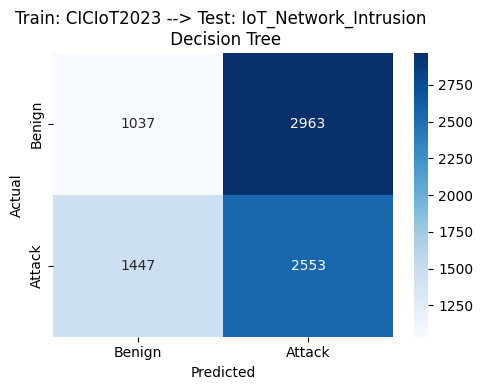


 [Random Forest]
Accuracy: 0.364625
F1 Score Weighted: 0.33790912633426234
F1 Score Attack: 0.4709066305818674
F1 Score Benign: 0.20491162208665728
Training time: 11.289915800094604 sec
Testing time: 0.1419694423675537 sec


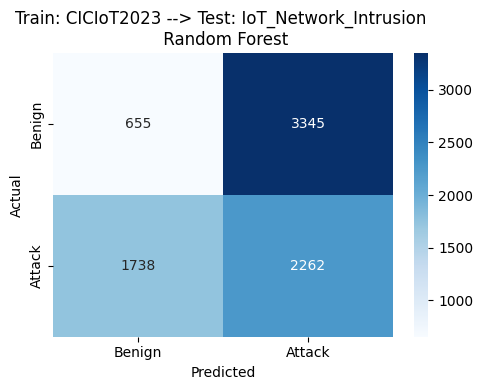


 [KNN]
Accuracy: 0.316
F1 Score Weighted: 0.3154823335147205
F1 Score Attack: 0.2966580976863753
F1 Score Benign: 0.3343065693430657
Training time: 0.03481245040893555 sec
Testing time: 3.1231701374053955 sec


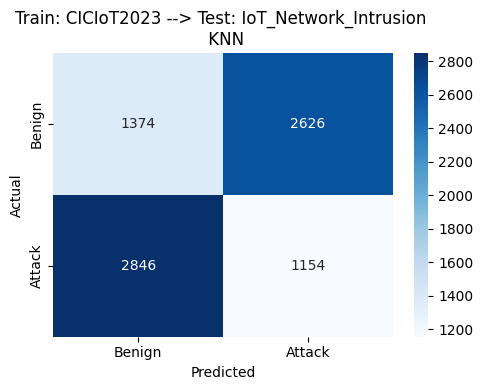


 [SVM]
Accuracy: 0.149125
F1 Score Weighted: 0.1491233913114117
F1 Score Attack: 0.1479534359744649
F1 Score Benign: 0.1502933466483585
Training time: 216.30688214302063 sec
Testing time: 7.943097114562988 sec


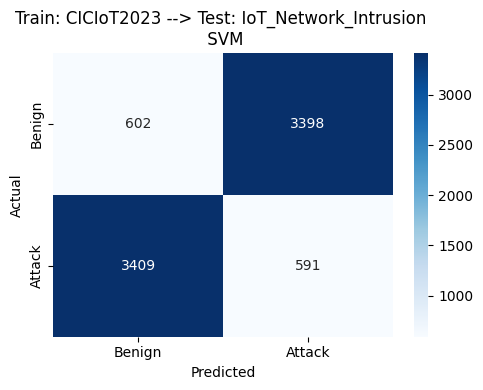


 [Logistic Regression]
Accuracy: 0.09125
F1 Score Weighted: 0.09107185008261619
F1 Score Attack: 0.10379684418145957
F1 Score Benign: 0.07834685598377282
Training time: 3.5570130348205566 sec
Testing time: 0.005293130874633789 sec


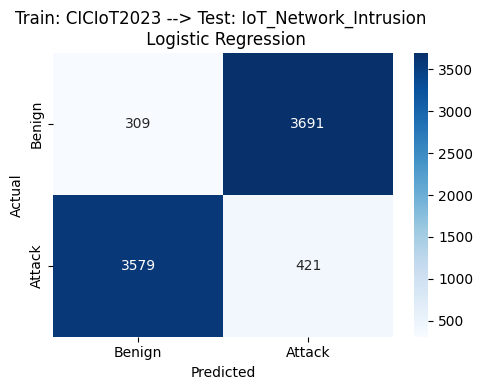


 [XGBoost]
Accuracy: 0.174
F1 Score Weighted: 0.16501213847176877
F1 Score Attack: 0.25164212910532274
F1 Score Benign: 0.07838214783821479
Training time: 5.902667045593262 sec
Testing time: 0.021034717559814453 sec


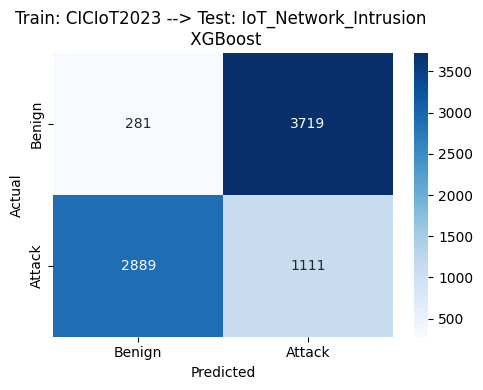


 [DNN]
Accuracy: 0.192875
F1 Score Weighted: 0.18193821698290621
F1 Score Attack: 0.2765266106442577
F1 Score Benign: 0.08734982332155478
Training time: 41.085947036743164 sec
Testing time: 0.012172222137451172 sec


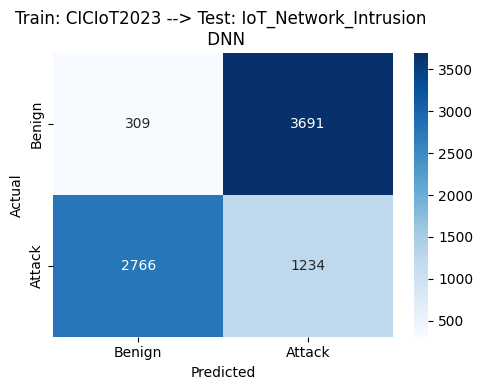

Train: CICIoT2023 --> Test: UQIoT

Training size: 32000 rows
Attack: 16000
Benign: 16000

 Testing size: 7061 rows
Attack: 3061
Benign: 4000

 [Decision Tree]
Accuracy: 0.4911485625265543
F1 Score Weighted: 0.4834236594342009
F1 Score Attack: 0.3605623776472682
F1 Score Benign: 0.5774432553216512
Training time: 5.217543840408325 sec
Testing time: 0.006402015686035156 sec


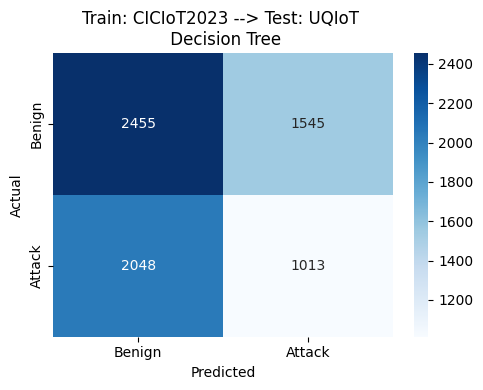


 [Random Forest]
Accuracy: 0.32870698201387905
F1 Score Weighted: 0.31673544779339385
F1 Score Attack: 0.3797435226380529
F1 Score Benign: 0.26851851851851855
Training time: 10.922629833221436 sec
Testing time: 0.1911635398864746 sec


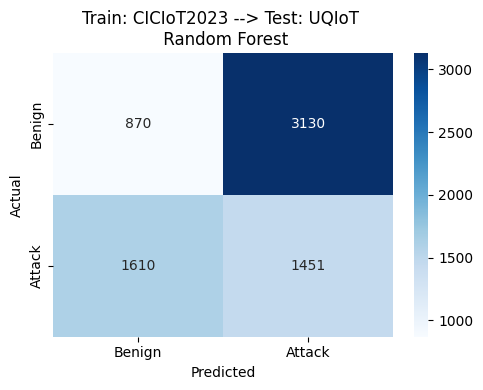


 [KNN]
Accuracy: 0.5504885993485342
F1 Score Weighted: 0.4965000665372675
F1 Score Attack: 0.26048462255358806
F1 Score Benign: 0.6771108850457782
Training time: 0.04327082633972168 sec
Testing time: 2.7810184955596924 sec


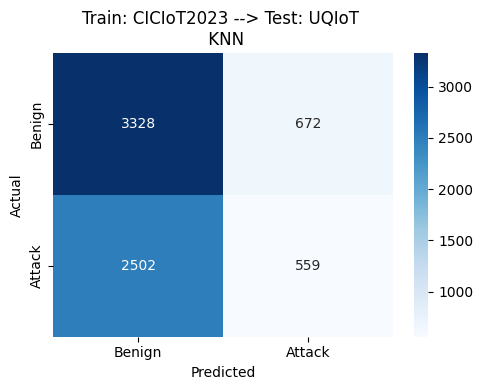


 [SVM]
Accuracy: 0.514516357456451
F1 Score Weighted: 0.45547748062634674
F1 Score Attack: 0.19906542056074766
F1 Score Benign: 0.6516968095915464
Training time: 212.67520594596863 sec
Testing time: 6.759413480758667 sec


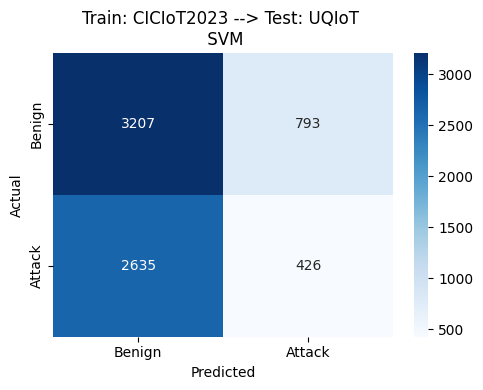


 [Logistic Regression]
Accuracy: 0.5871689562384931
F1 Score Weighted: 0.5837469974564556
F1 Score Attack: 0.6053878435088669
F1 Score Benign: 0.5671863400148478
Training time: 3.413518190383911 sec
Testing time: 0.004343271255493164 sec


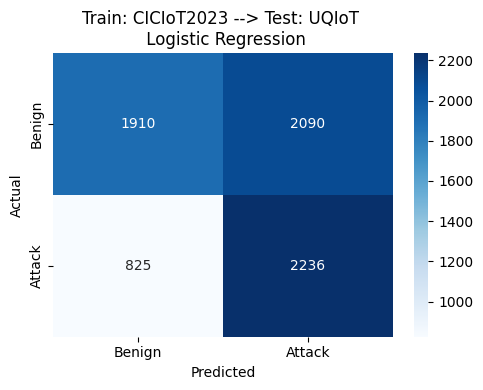


 [XGBoost]
Accuracy: 0.6181843931454468
F1 Score Weighted: 0.5649057511844071
F1 Score Attack: 0.34942084942084944
F1 Score Benign: 0.7298055722589697
Training time: 6.021499156951904 sec
Testing time: 0.01990795135498047 sec


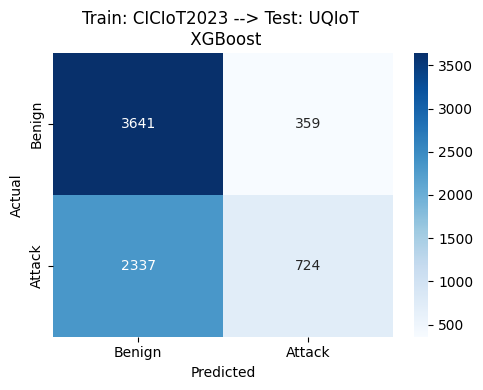


 [DNN]
Accuracy: 0.5460982863617051
F1 Score Weighted: 0.5464099960962998
F1 Score Attack: 0.543642318097679
F1 Score Benign: 0.5485279616847444
Training time: 41.22017288208008 sec
Testing time: 0.01129913330078125 sec


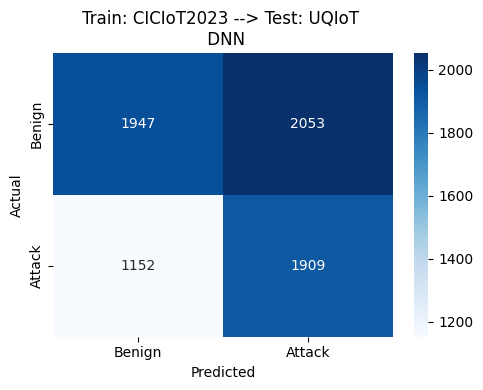

Train: IoT_Network_Intrusion --> Test: CICIoT2023

Training size: 32000 rows
Attack: 16000
Benign: 16000

 Testing size: 8000 rows
Attack: 4000
Benign: 4000

 [Decision Tree]
Accuracy: 0.1415
F1 Score Weighted: 0.13476146823722326
F1 Score Attack: 0.05840416780915821
F1 Score Benign: 0.2111187686652883
Training time: 2.0702414512634277 sec
Testing time: 0.0069468021392822266 sec


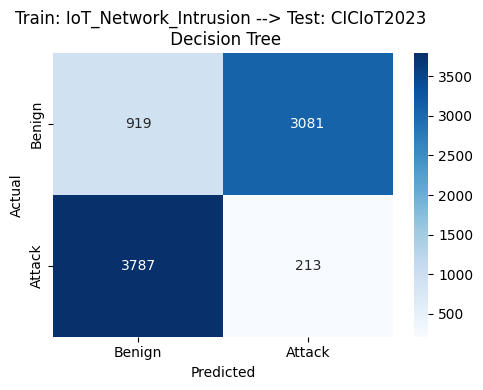


 [Random Forest]
Accuracy: 0.335875
F1 Score Weighted: 0.26161711376407093
F1 Score Attack: 0.027457440966501923
F1 Score Benign: 0.4957767865616399
Training time: 8.01832103729248 sec
Testing time: 0.15373015403747559 sec


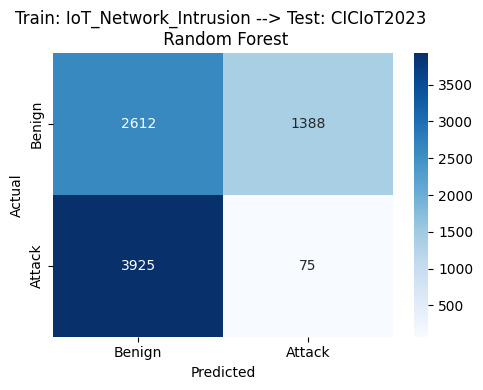


 [KNN]
Accuracy: 0.36875
F1 Score Weighted: 0.3437979157462512
F1 Score Attack: 0.47175732217573224
F1 Score Benign: 0.21583850931677018
Training time: 0.029727458953857422 sec
Testing time: 3.251188039779663 sec


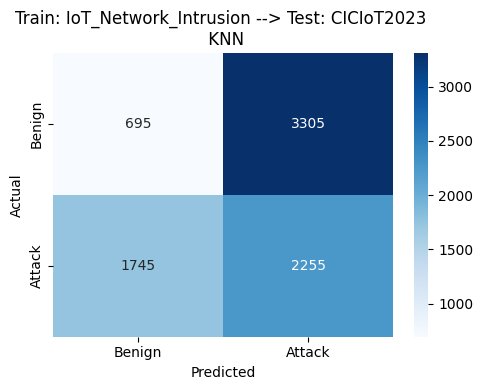


 [SVM]
Accuracy: 0.267125
F1 Score Weighted: 0.2670851363024917
F1 Score Attack: 0.26167988918272256
F1 Score Benign: 0.27249038342226084
Training time: 35.41561841964722 sec
Testing time: 1.2776122093200684 sec


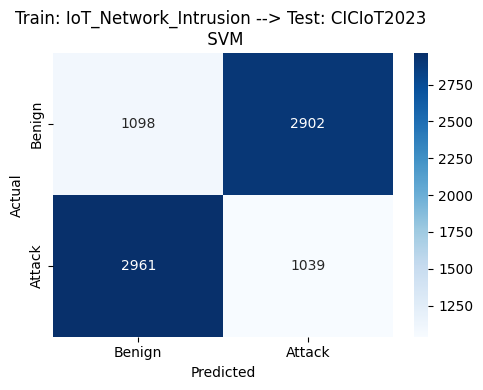


 [Logistic Regression]
Accuracy: 0.280125
F1 Score Weighted: 0.24993457359280313
F1 Score Attack: 0.40041644976574703
F1 Score Benign: 0.09945269741985927
Training time: 1.9560496807098389 sec
Testing time: 0.005313396453857422 sec


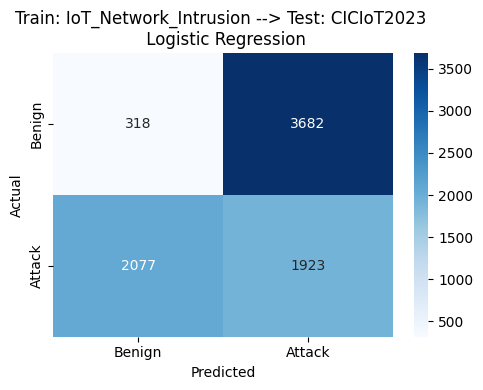


 [XGBoost]
Accuracy: 0.04325
F1 Score Weighted: 0.04314947089128552
F1 Score Attack: 0.052957188814649836
F1 Score Benign: 0.03334175296792119
Training time: 3.8239543437957764 sec
Testing time: 0.013380765914916992 sec


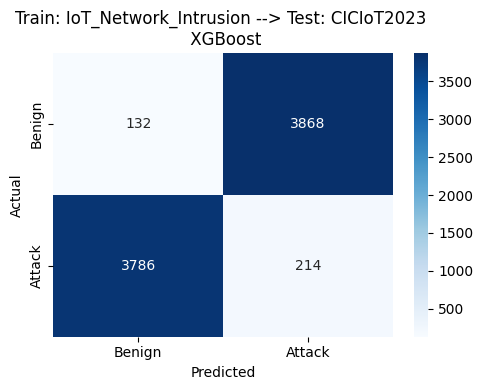


 [DNN]
Accuracy: 0.3745
F1 Score Weighted: 0.3611608794532027
F1 Score Attack: 0.2688486265341905
F1 Score Benign: 0.4534731323722149
Training time: 14.679119348526001 sec
Testing time: 0.012524843215942383 sec


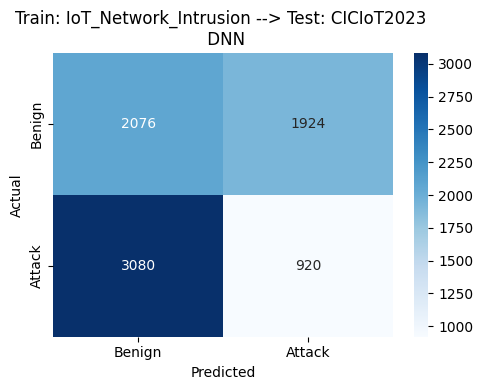

Train: IoT_Network_Intrusion --> Test: UQIoT

Training size: 32000 rows
Attack: 16000
Benign: 16000

 Testing size: 7061 rows
Attack: 3061
Benign: 4000

 [Decision Tree]
Accuracy: 0.30052400509842797
F1 Score Weighted: 0.25760904185857403
F1 Score Attack: 0.41012779171145347
F1 Score Benign: 0.14089406853365802
Training time: 2.191498279571533 sec
Testing time: 0.006454944610595703 sec


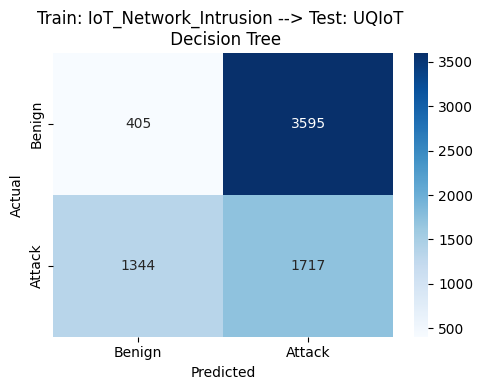


 [Random Forest]
Accuracy: 0.5994901572015295
F1 Score Weighted: 0.5392895981162532
F1 Score Attack: 0.3048180924287119
F1 Score Benign: 0.7187189178436443
Training time: 8.132150650024414 sec
Testing time: 0.13591909408569336 sec


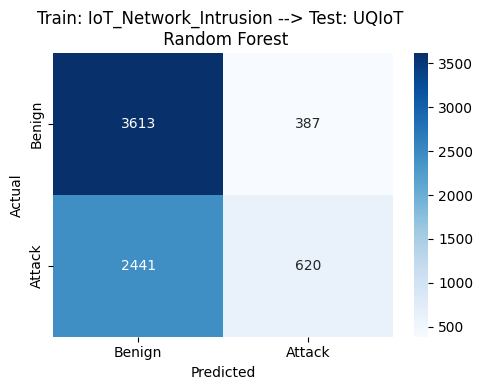


 [KNN]
Accuracy: 0.43435773969692676
F1 Score Weighted: 0.4222346330244517
F1 Score Attack: 0.27116788321167884
F1 Score Benign: 0.5378384633186762
Training time: 0.03852343559265137 sec
Testing time: 2.738893747329712 sec


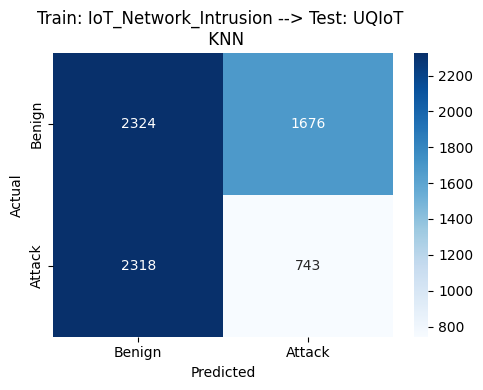


 [SVM]
Accuracy: 0.3498088089505736
F1 Score Weighted: 0.33394053927082923
F1 Score Attack: 0.41027617212588313
F1 Score Benign: 0.2755246962284993
Training time: 35.15857005119324 sec
Testing time: 1.1245334148406982 sec


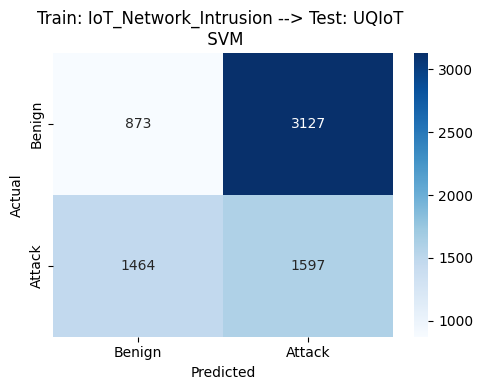


 [Logistic Regression]
Accuracy: 0.4107066987678799
F1 Score Weighted: 0.3521684314259962
F1 Score Attack: 0.5271053528810092
F1 Score Benign: 0.21829795228254745
Training time: 2.053149461746216 sec
Testing time: 0.004595756530761719 sec


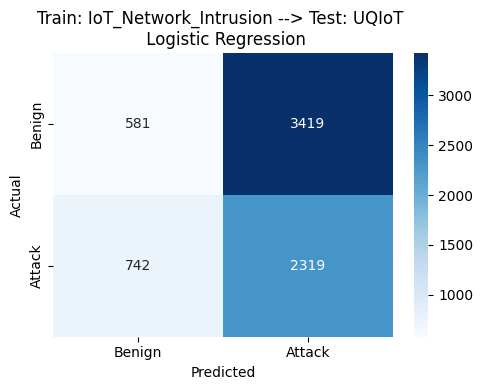


 [XGBoost]
Accuracy: 0.32290043903129867
F1 Score Weighted: 0.26822117138784285
F1 Score Attack: 0.4443927948866938
F1 Score Benign: 0.1334058365053471
Training time: 5.778025150299072 sec
Testing time: 0.01469564437866211 sec


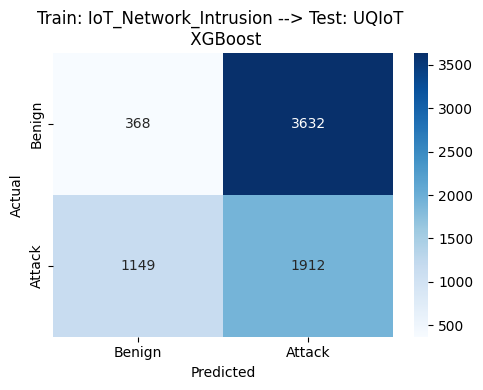


 [DNN]
Accuracy: 0.35150828494547515
F1 Score Weighted: 0.3539790566751138
F1 Score Attack: 0.32333382591990545
F1 Score Benign: 0.37743031951053707
Training time: 14.305164813995361 sec
Testing time: 0.010439634323120117 sec


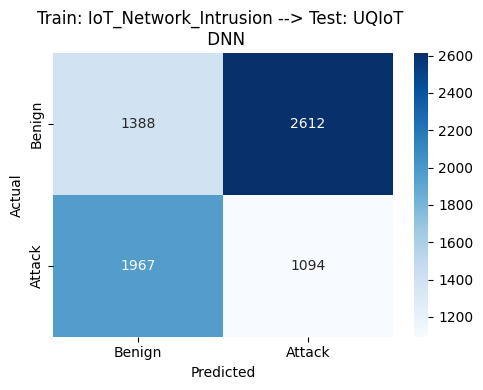

Train: UQIoT --> Test: CICIoT2023

Training size: 24482 rows
Attack: 12241
Benign: 12241

 Testing size: 8000 rows
Attack: 4000
Benign: 4000

 [Decision Tree]
Accuracy: 0.301125
F1 Score Weighted: 0.2975966413536271
F1 Score Attack: 0.3473794793976888
F1 Score Benign: 0.24781380330956546
Training time: 4.214730501174927 sec
Testing time: 0.007837772369384766 sec


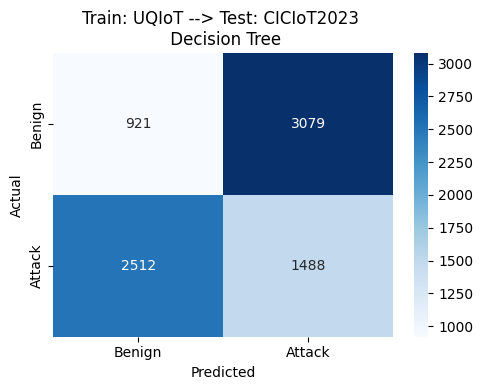


 [Random Forest]
Accuracy: 0.107375
F1 Score Weighted: 0.10189339228690739
F1 Score Attack: 0.17205797101449274
F1 Score Benign: 0.031728813559322035
Training time: 8.719642639160156 sec
Testing time: 0.16205263137817383 sec


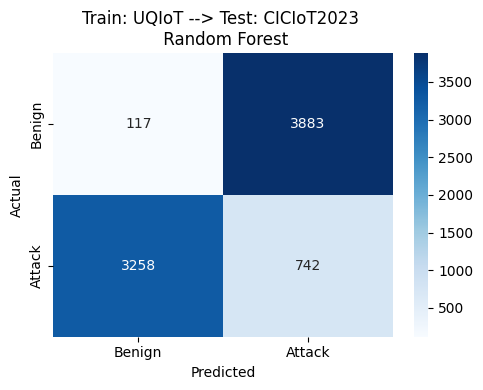


 [KNN]
Accuracy: 0.296
F1 Score Weighted: 0.2943056278123775
F1 Score Attack: 0.259726603575184
F1 Score Benign: 0.328884652049571
Training time: 0.02382040023803711 sec
Testing time: 2.4117634296417236 sec


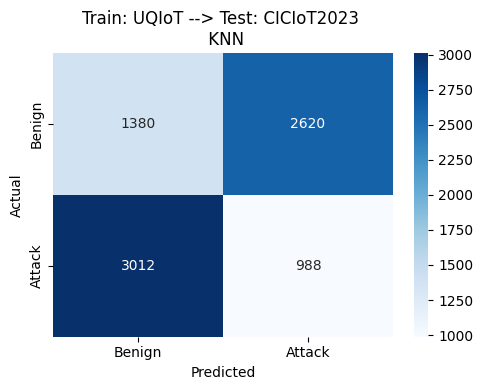


 [SVM]
Accuracy: 0.591875
F1 Score Weighted: 0.5807881500558224
F1 Score Attack: 0.6489624771529943
F1 Score Benign: 0.5126138229586505
Training time: 480.95901441574097 sec
Testing time: 30.156939029693604 sec


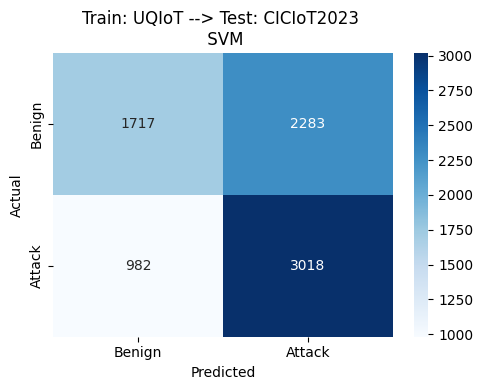


 [Logistic Regression]
Accuracy: 0.149375
F1 Score Weighted: 0.1396394694281142
F1 Score Attack: 0.048118617988529865
F1 Score Benign: 0.23116032086769855
Training time: 6.42406964302063 sec
Testing time: 0.005869865417480469 sec


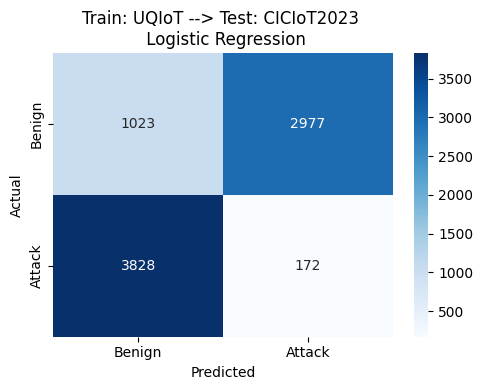


 [XGBoost]
Accuracy: 0.29375
F1 Score Weighted: 0.25412127697605713
F1 Score Attack: 0.42604632263307596
F1 Score Benign: 0.08219623131903833
Training time: 4.677699089050293 sec
Testing time: 0.021902799606323242 sec


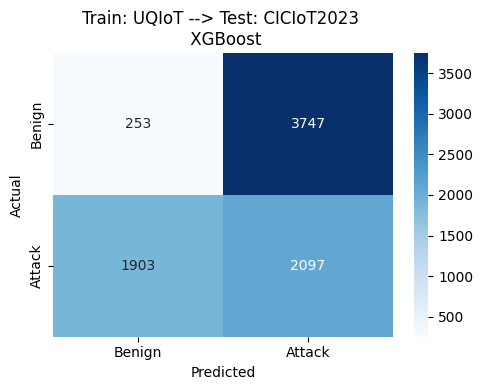


 [DNN]
Accuracy: 0.27975
F1 Score Weighted: 0.2703504723727235
F1 Score Attack: 0.18753525098702764
F1 Score Benign: 0.3531656937584194
Training time: 25.54667019844055 sec
Testing time: 0.015403985977172852 sec


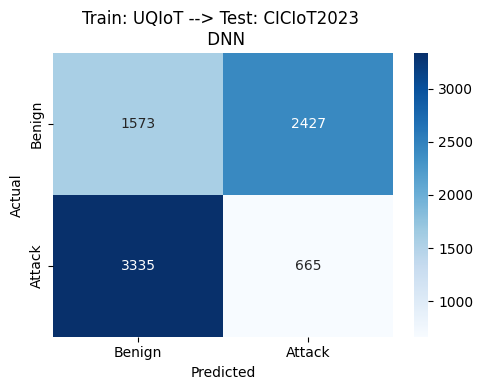

Train: UQIoT --> Test: IoT_Network_Intrusion

Training size: 24482 rows
Attack: 12241
Benign: 12241

 Testing size: 8000 rows
Attack: 4000
Benign: 4000

 [Decision Tree]
Accuracy: 0.565125
F1 Score Weighted: 0.5422329194630106
F1 Score Attack: 0.6446010828480948
F1 Score Benign: 0.43986475607792624
Training time: 4.299067735671997 sec
Testing time: 0.006947517395019531 sec


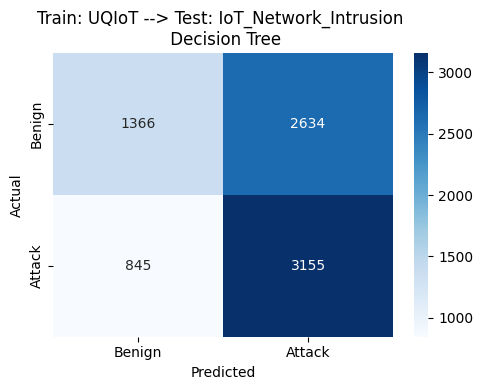


 [Random Forest]
Accuracy: 0.505625
F1 Score Weighted: 0.3732130306475254
F1 Score Attack: 0.6612999914361566
F1 Score Benign: 0.08512606985889429
Training time: 10.806788444519043 sec
Testing time: 0.17986273765563965 sec


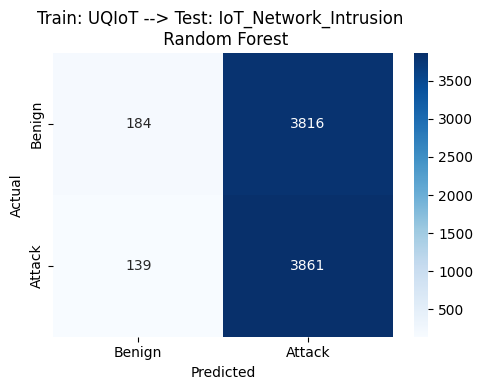


 [KNN]
Accuracy: 0.43675
F1 Score Weighted: 0.4129129446050921
F1 Score Attack: 0.531210986267166
F1 Score Benign: 0.2946149029430182
Training time: 0.025864124298095703 sec
Testing time: 2.4658238887786865 sec


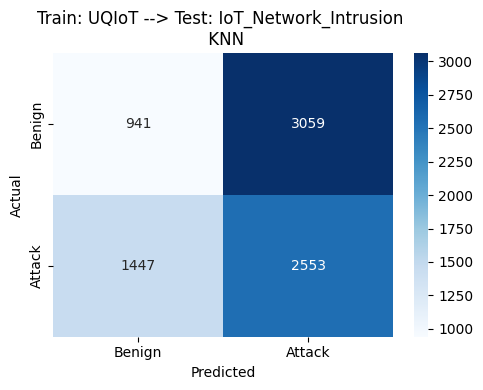


 [SVM]
Accuracy: 0.304125
F1 Score Weighted: 0.2445249987400551
F1 Score Attack: 0.4567190397189421
F1 Score Benign: 0.03233095776116809
Training time: 470.70608377456665 sec
Testing time: 29.06931447982788 sec


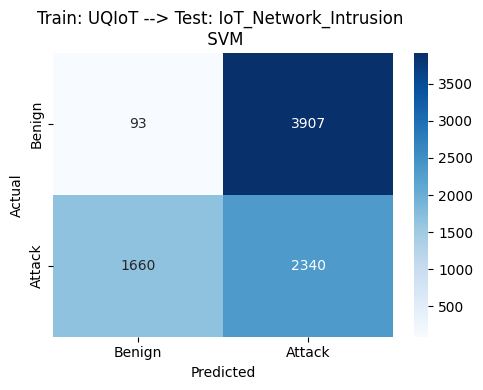


 [Logistic Regression]
Accuracy: 0.912875
F1 Score Weighted: 0.912843121009683
F1 Score Attack: 0.9111762456989932
F1 Score Benign: 0.9145099963203729
Training time: 6.131495237350464 sec
Testing time: 0.00574040412902832 sec


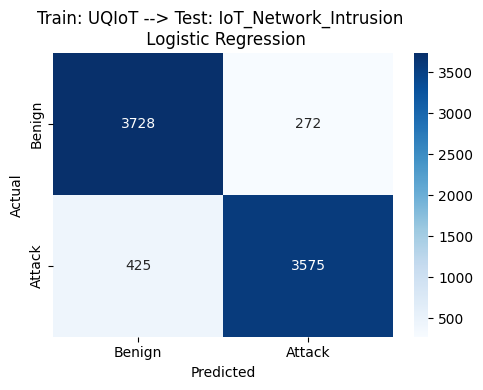


 [XGBoost]
Accuracy: 0.71225
F1 Score Weighted: 0.6955435417372178
F1 Score Attack: 0.7668624670852745
F1 Score Benign: 0.6242246163891609
Training time: 4.366059064865112 sec
Testing time: 0.020064353942871094 sec


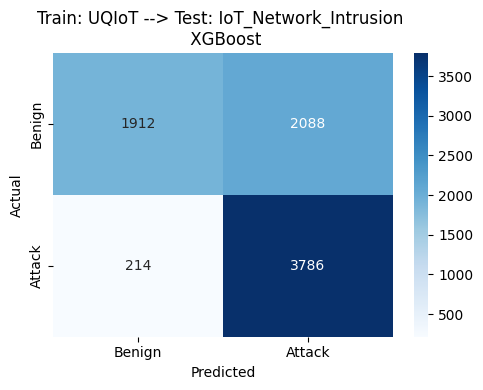


 [DNN]
Accuracy: 0.5925
F1 Score Weighted: 0.5882581323439403
F1 Score Attack: 0.5464663327768503
F1 Score Benign: 0.6300499319110304
Training time: 24.62460231781006 sec
Testing time: 0.013371706008911133 sec


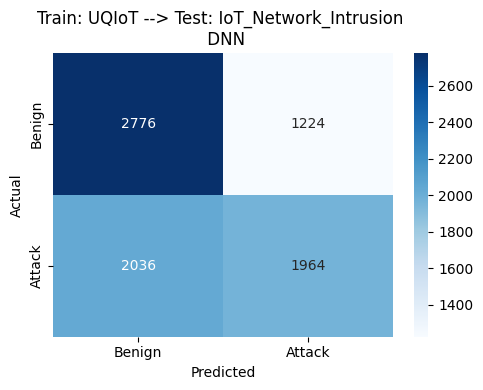

All 6 Combination of Cross-dataset evaluaion is done
Trained models stored for 6 combinations
{'CICIoT2023 -> IoT_Network_Intrusion': ({'Decision Tree': DecisionTreeClassifier(random_state=42), 'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42), 'KNN': KNeighborsClassifier(n_jobs=-1), 'SVM': SVC(probability=True, random_state=42), 'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42), 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_

In [8]:
# Run all 6 Cross-dataset combination

feature_columns=ciciot_features

all_results=[]

trained_combinations={}

# Combination 1: Train on CICIoT2023 Dataset and Test on IoT Network Intrusion Dataset
results, models_1, X_train_1, X_test_1= run_cross_dataset(ciciot_train, iot_nid_test, "CICIoT2023", "IoT_Network_Intrusion", feature_columns)
all_results.extend(results)
trained_combinations["CICIoT2023 -> IoT_Network_Intrusion"] = (models_1, X_train_1, X_test_1)

# Combination 2: Train on CICIoT2023 Dataset and Test on UQIoT Dataset
results, models_2, X_train_2, X_test_2= run_cross_dataset(ciciot_train, uqiot_test, "CICIoT2023", "UQIoT", feature_columns)
all_results.extend(results)
trained_combinations["CICIoT2023 -> UQIoT"] = (models_2, X_train_2, X_test_2)

# Combination 3: Train on IOT_Network_Intrusion_Dataset and Test on CICIOT2023
results, models_3, X_train_3, X_test_3= run_cross_dataset(iot_nid_train, ciciot_test, "IoT_Network_Intrusion", "CICIoT2023", feature_columns)
all_results.extend(results)
trained_combinations["IoT_Network_Intrusion -> CICIoT2023"] = (models_3, X_train_3, X_test_3)

# Combination 4: Train on IOT_Network_Intrusion_Dataset and Test on UQIOT Dataset
results, models_4, X_train_4, X_test_4= run_cross_dataset(iot_nid_train, uqiot_test, "IoT_Network_Intrusion" , "UQIoT", feature_columns)
all_results.extend(results)
trained_combinations["IoT_Network_Intrusion -> UQIoT"] = (models_4, X_train_4, X_test_4)

# Combination 5: Train on UQIoT Dataset and Test on CICIoT2023 Dataset
results, models_5, X_train_5, X_test_5= run_cross_dataset(uqiot_train, ciciot_test, "UQIoT", "CICIoT2023", feature_columns)
all_results.extend(results)
trained_combinations["UQIoT -> CICIoT2023"] = (models_5, X_train_5, X_test_5)

# Combination 6: Train on UQIoT Dataset and Test on IoT Network Intrusion Dataset
results, models_6, X_train_6, X_test_6= run_cross_dataset(uqiot_train, iot_nid_test, "UQIoT", "IoT_Network_Intrusion", feature_columns)
all_results.extend(results)
trained_combinations["UQIoT -> IoT_Network_Intrusion"] = (models_6, X_train_6, X_test_6)

print("All 6 Combination of Cross-dataset evaluaion is done")
print(f"Trained models stored for {len(trained_combinations)} combinations")
print(trained_combinations)
print(all_results)

In [9]:
# Save the results in CSV

results_df=pd.DataFrame(all_results)
results_csv_path=os.path.join(Output_Dir, "cross_dataset_evaluation_results.csv")
results_df.to_csv(results_csv_path, index=False)

print(f"Results saved in: {results_csv_path}")
print(f"Total number of rows in results table: {len(results_df)}")
print("(6 comnibations X 6 models = 36 rows)")
print(results_df.to_string(index=False))


Results saved in: C:\Users\NARASIMHA N\OneDrive\Desktop\comparative_analysis_arp_spoofing\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\Cross-Dataset Evaluation\Outputs\cross_dataset_evaluation_results.csv
Total number of rows in results table: 42
(6 comnibations X 6 models = 36 rows)
        Train Dataset          Test Dataset               Model  Accuracy  F1 Weighted  F1 Attack  F1 Benign  Training time  Testing time
           CICIoT2023 IoT_Network_Intrusion       Decision Tree  0.448750     0.428217   0.536570   0.319864       3.810707      0.006626
           CICIoT2023 IoT_Network_Intrusion       Random Forest  0.364625     0.337909   0.470907   0.204912      11.289916      0.141969
           CICIoT2023 IoT_Network_Intrusion                 KNN  0.316000     0.315482   0.296658   0.334307       0.034812      3.123170
           CICIoT2023 IoT_Network_Intrusion                 SVM  0.149125     0.149123   0.147953   0.150293     216.306882  

In [10]:
#Finding the best model per combination

best_per_combination= (
    results_df.sort_values('F1 Weighted',ascending=False).groupby(['Train Dataset', 'Test Dataset'],sort=False).first().reset_index()
)[["Train Dataset", "Test Dataset", "Model", "Accuracy", "F1 Weighted", "F1 Attack", "F1 Benign"]]

print("Best model per cross-dataset combination:\n")
print(best_per_combination.to_string(index=False))

Best model per cross-dataset combination:

        Train Dataset          Test Dataset               Model  Accuracy  F1 Weighted  F1 Attack  F1 Benign
                UQIoT IoT_Network_Intrusion Logistic Regression  0.912875     0.912843   0.911176   0.914510
           CICIoT2023                 UQIoT Logistic Regression  0.587169     0.583747   0.605388   0.567186
                UQIoT            CICIoT2023                 SVM  0.591875     0.580788   0.648962   0.512614
IoT_Network_Intrusion                 UQIoT       Random Forest  0.599490     0.539290   0.304818   0.718719
           CICIoT2023 IoT_Network_Intrusion       Decision Tree  0.448750     0.428217   0.536570   0.319864
IoT_Network_Intrusion            CICIoT2023                 DNN  0.374500     0.361161   0.268849   0.453473


Model,Decision Tree,Random Forest,KNN,SVM,Logistic Regression,XGBoost,DNN
Combinations,,,,,,,
CICIoT2023-->IoT_Network_Intrusion,0.4282,0.3379,0.3155,0.1491,0.0911,0.1650,0.1819
CICIoT2023-->UQIoT,0.4834,0.3167,0.4965,0.4555,0.5837,0.5649,0.5464
IoT_Network_Intrusion-->CICIoT2023,0.1348,0.2616,0.3438,0.2671,0.2499,0.0431,0.3612
IoT_Network_Intrusion-->UQIoT,0.2576,0.5393,0.4222,0.3339,0.3522,0.2682,0.3540
UQIoT-->CICIoT2023,0.2976,0.1019,0.2943,0.5808,0.1396,0.2541,0.2704
UQIoT-->IoT_Network_Intrusion,0.5422,0.3732,0.4129,0.2445,0.9128,0.6955,0.5883


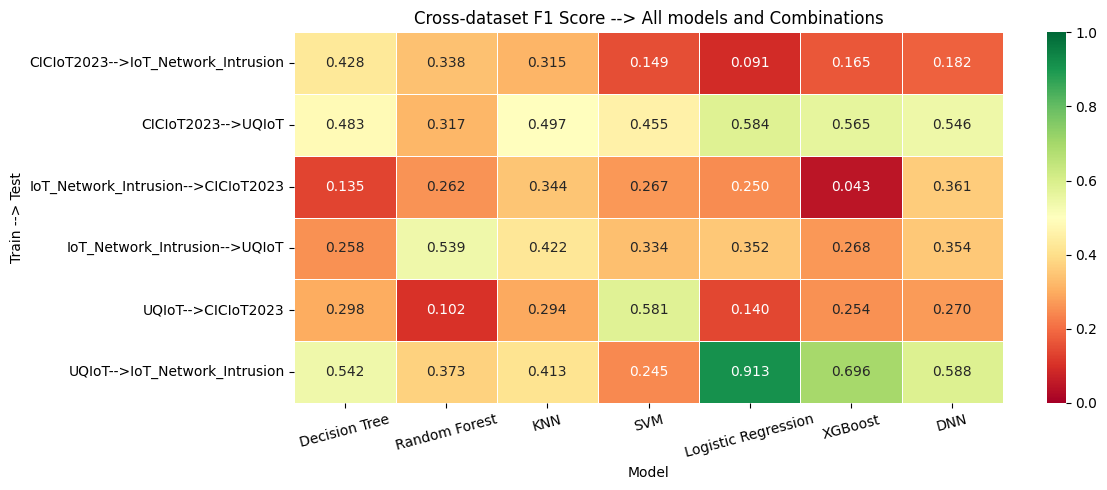

Heatmap saved to C:\Users\NARASIMHA N\OneDrive\Desktop\comparative_analysis_arp_spoofing\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\Cross-Dataset Evaluation\Outputs\Cross-dataset_heatmap.png


In [11]:
#Creating a table with train --> test combinations as rows and models as columns to easily see which model generalize best accross all combinations

results_df['Combinations']=results_df['Train Dataset'] + "-->" + results_df["Test Dataset"]

#using pivot to create a table thta contains combinations as rows, models as columns and F1 scores as values
pivot=results_df.pivot(index='Combinations', columns="Model", values="F1 Weighted")

#reorder the columns to match within-dataset notebook order
model_order=["Decision Tree", "Random Forest", "KNN", "SVM", "Logistic Regression", "XGBoost", "DNN"]

pivot=pivot[model_order]

display(pivot.round(4))

fig, ax = plt.subplots(figsize=(12,5))
sbn.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Cross-dataset F1 Score --> All models and Combinations')
ax.set_xlabel('Model')
ax.set_ylabel('Train --> Test')
ax.tick_params(axis='x', rotation =15)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

heatmap_path= os.path.join(Output_Dir, "Cross-dataset_heatmap.png")
plt.savefig(heatmap_path, dpi=150)
plt.show()
plt.close()

print(f"Heatmap saved to {heatmap_path}")

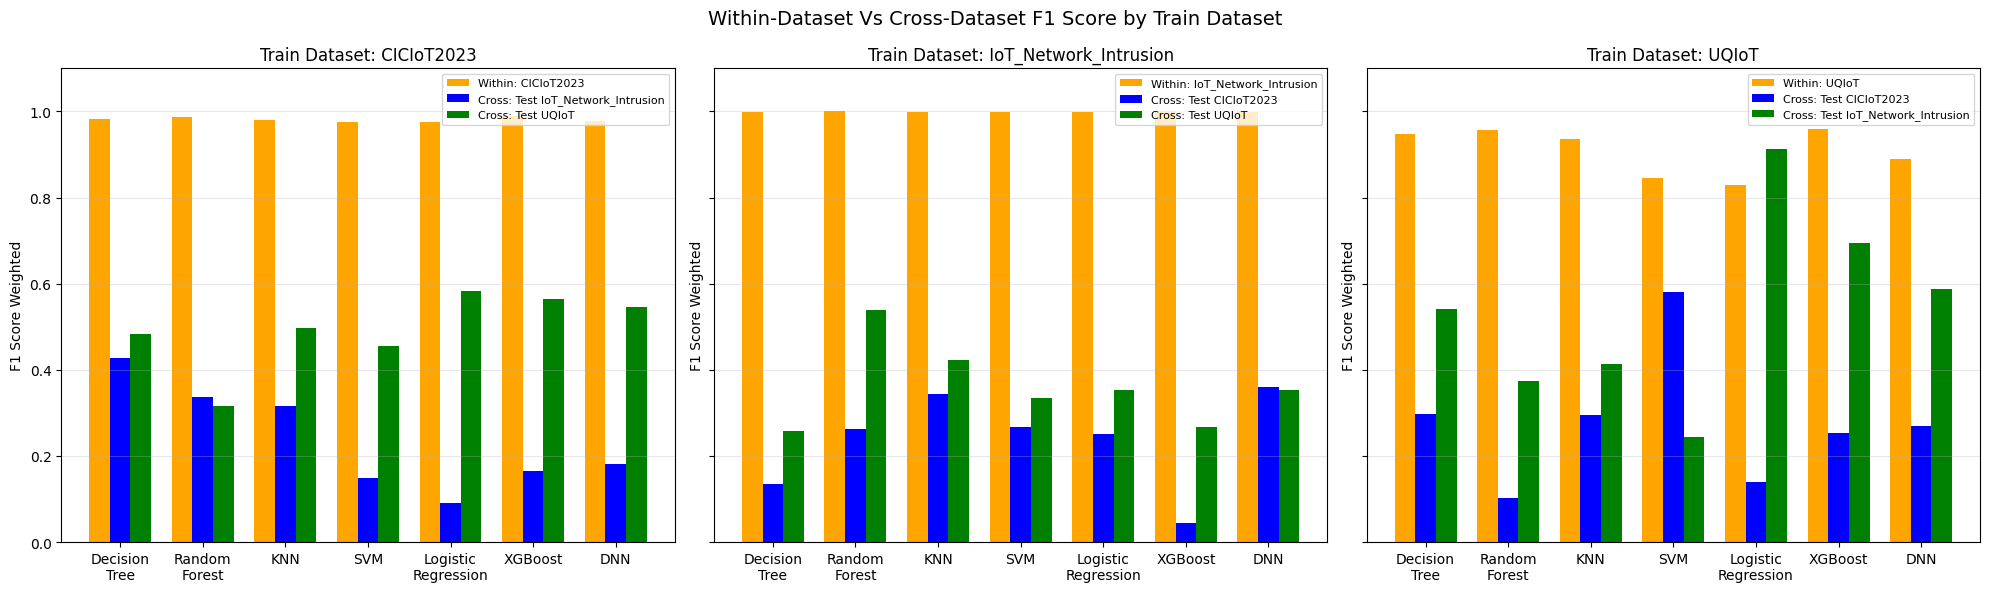

Bar chart sahve in: C:\Users\NARASIMHA N\OneDrive\Desktop\comparative_analysis_arp_spoofing\comparative_analysis_arp_spoofing\Kitsune Feature Extraction\Dataset Preprocessing\Cross-Dataset Evaluation\Outputs\within_vs_cross_dataset_comparison.png


In [12]:
# Drawing bar chart to compare the performance of the models within dataset and cross dataset performance

within_dataset_scores = {
    "Decision Tree": {"CICIoT2023": 0.9832, "IoT_Network_Intrusion": 0.9995, "UQIoT": 0.9482},
    "Random Forest": {"CICIoT2023": 0.9867, "IoT_Network_Intrusion": 0.9999, "UQIoT": 0.9574},
    "KNN": {"CICIoT2023": 0.9803, "IoT_Network_Intrusion": 0.9991, "UQIoT":0.9360},
    "SVM": {"CICIoT2023": 0.9743, "IoT_Network_Intrusion": 0.9991, "UQIoT": 0.8464},
    "Logistic Regression": {"CICIoT2023": 0.9747, "IoT_Network_Intrusion": 0.9993, "UQIoT": 0.8283},
    "XGBoost": {"CICIoT2023": 0.9886, "IoT_Network_Intrusion": 0.9999, "UQIoT": 0.9583},
    "DNN":{"CICIoT2023": 0.9769, "IoT_Network_Intrusion": 0.9976 , "UQIoT": 0.8898}
}

cross_test_targets = {
    "CICIoT2023": ["IoT_Network_Intrusion","UQIoT"],
    "IoT_Network_Intrusion": ["CICIoT2023","UQIoT"],
    "UQIoT": ["CICIoT2023","IoT_Network_Intrusion"]
}

datasets= ["CICIoT2023","IoT_Network_Intrusion","UQIoT"]
model_names=list(within_dataset_scores.keys())

fig, axes=plt.subplots(1,3,figsize=(20,6), sharey=True)

for ax, train_dataset in zip(axes, datasets):
    test_target_1=cross_test_targets[train_dataset][0]
    test_target_2=cross_test_targets[train_dataset][1]

    within_scores=[within_dataset_scores[model][train_dataset] for model in model_names]

    cross_scores_1=[]
    for model in model_names:
        row=results_df[(results_df["Train Dataset"]==train_dataset) & (results_df["Test Dataset"]==test_target_1) & (results_df["Model"]==model)]['F1 Weighted'].values
        cross_scores_1.append(float(row[0]) if len(row) > 0 else 0)

    cross_scores_2=[]
    for model in model_names:
        row=results_df[(results_df["Train Dataset"]==train_dataset) & (results_df["Test Dataset"]==test_target_2) & (results_df["Model"]==model)]['F1 Weighted'].values
        cross_scores_2.append(float(row[0]) if len(row) > 0 else 0)

    x=np.arange(len(model_names))

    width=0.25

    ax.bar(x-width, within_scores, width, label=f"Within: {train_dataset}", color='orange')
    ax.bar(x, cross_scores_1, width, label=f"Cross: Test {test_target_1}", color='blue')
    ax.bar(x+width, cross_scores_2, width, label=f"Cross: Test {test_target_2}", color='green')

    ax.set_title(f"Train Dataset: {train_dataset}")
    ax.set_xticks(x)
    ax.set_xticklabels([model.replace(' ','\n') for model in model_names])
    ax.set_ylim(0,1.1)
    ax.set_ylabel("F1 Score Weighted")
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Within-Dataset Vs Cross-Dataset F1 Score by Train Dataset', fontsize=14)
plt.tight_layout()


bar_chart_path=os.path.join(Output_Dir,"within_vs_cross_dataset_comparison.png")
plt.savefig(bar_chart_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print(f"Bar chart sahve in: {bar_chart_path}")        

In [13]:
#Printing the summary of both within and Cross Dataset Evaluation

print("SUMMARY")

print("\n 1. Average Cross Dataset F1 score per model:")
average_by_model=(results_df.groupby("Model")["F1 Weighted"].mean().sort_values(ascending=False).round(4))

for model, score in average_by_model.items():
    print(f"{model}: {score}")

print("\n 2. Average cross-dataset F1 score per training dataset:")

average_by_train=(results_df.groupby("Train Dataset")["F1 Weighted"].mean().sort_values(ascending=False).round(4))

for dataset, score in average_by_train.items():
    print(f"{dataset}: {score}")

print("\n 3. Average cross-dataset F1 score per Test dataset:")

average_by_test=(results_df.groupby("Test Dataset")["F1 Weighted"].mean().sort_values(ascending=False).round(4))

for dataset, score in average_by_test.items():
    print(f"{dataset}: {score}")

print("\n 4. Best Model per Train --> Test Combination:")
best_per_combination=(results_df.sort_values("F1 Weighted", ascending=False).groupby(["Train Dataset", "Test Dataset"], sort=False).first().reset_index())

for _, row in best_per_combination.iterrows():
    print(f"{row['Train Dataset']} --> {row['Test Dataset']}")
    print(f"Best Model: {row['Model']}")
    print(f" F1 Score: {round(row['F1 Weighted'],4)}")
    print(f"Accuracy: {round(row['Accuracy'],4)}")

print("\n 5. Standout result:")
best_row=results_df.loc[results_df["F1 Weighted"].idxmax()]
print(f"Train dataset: {best_row["Train Dataset"]}")
print(f"Test dataset: {best_row["Test Dataset"]}")
print(f"Model: {best_row["Model"]}")
print(f"F1 Score: {round(best_row["F1 Weighted"],4)}")
print(f"Accuracy: {round(best_row["Accuracy"],4)}")

print("\n 6. Worst result:")
worst_row=results_df.loc[results_df["F1 Weighted"].idxmin()]
print(f"Train dataset: {worst_row["Train Dataset"]}")
print(f"Test dataset: {worst_row["Test Dataset"]}")
print(f"Model: {worst_row["Model"]}")
print(f"F1 Score: {round(worst_row["F1 Weighted"],4)}")
print(f"Accuracy: {round(worst_row["Accuracy"],4)}")

print("\n 7. Within- Dataset Vs Cross-Dataset Performance Gap:")

within_average={
    "CICIoT2023": round((0.9832+0.9867+0.9803+0.9743+0.9747+0.9886)/6,4),
    "IoT_Network_Intrusion": round((0.9995+0.9999+0.9991+0.9991+0.9993+0.9999)/6,4),
    "UQIoT": round((0.9482+0.9457+0.9360+0.8464+0.8283+0.9583)/6,4)
}

for dataset in ["CICIoT2023", "IoT_Network_Intrusion", "UQIoT"]:
    cross_average=round(results_df[results_df["Train Dataset"]==dataset]["F1 Weighted"].mean(), 4)

    within=within_average[dataset]
    gap=round(within-cross_average,4)
    print(f"{dataset}")
    print(f" Within-Dataset average F1 Score: {within}")
    print(f" Cross-Dataset average F1 Score: {cross_average}")
    print(f"Generalization Gap: {gap}")


SUMMARY

 1. Average Cross Dataset F1 score per model:
Logistic Regression: 0.3882
DNN: 0.3837
KNN: 0.3809
Decision Tree: 0.3573
SVM: 0.3385
XGBoost: 0.3318
Random Forest: 0.3218

 2. Average cross-dataset F1 score per training dataset:
UQIoT: 0.4077
CICIoT2023: 0.3654
IoT_Network_Intrusion: 0.2992

 3. Average cross-dataset F1 score per Test dataset:
UQIoT: 0.4268
IoT_Network_Intrusion: 0.3884
CICIoT2023: 0.2572

 4. Best Model per Train --> Test Combination:
UQIoT --> IoT_Network_Intrusion
Best Model: Logistic Regression
 F1 Score: 0.9128
Accuracy: 0.9129
CICIoT2023 --> UQIoT
Best Model: Logistic Regression
 F1 Score: 0.5837
Accuracy: 0.5872
UQIoT --> CICIoT2023
Best Model: SVM
 F1 Score: 0.5808
Accuracy: 0.5919
IoT_Network_Intrusion --> UQIoT
Best Model: Random Forest
 F1 Score: 0.5393
Accuracy: 0.5995
CICIoT2023 --> IoT_Network_Intrusion
Best Model: Decision Tree
 F1 Score: 0.4282
Accuracy: 0.4487
IoT_Network_Intrusion --> CICIoT2023
Best Model: DNN
 F1 Score: 0.3612
Accuracy: 0.37

In [18]:
#SHAP analysis for cross-dataset evaluation
# here I am using the already trained models and scaled dataframes from run_cross_dataset() function

def shap_for_combination(models, X_train_df, X_test_df, train_name, test_name):
    print("\nRunning SHAP for : Train: {train_name} --> Test:{test_name}")

    X_train_sample=shap.sample(X_train_df, 100, random_state=42)
    X_test_sample= X_test_df.sample(200, random_state=42)

    print(f"X_train sample (from {train_name}): {X_train_sample.shape}")
    print(f"X_test sample (from {test_name}): {X_test_sample.shape}")

    all_shap_values={}
    
    # SHAP calculation for tree-based models
    tree_models=["Decision Tree","Random Forest","XGBoost"]
    for model_name in tree_models:
        print(f"\n Computing SHAP for {model_name}...")
        explainer=shap.TreeExplainer(models[model_name])
        shap_values=explainer.shap_values(X_test_sample, check_additivity=False)

        shap_values=np.array(shap_values)
        if shap_values.ndim==3:
            shap_values=shap_values[:,:,1]

        all_shap_values[model_name]=shap_values

        plt.figure()
        shap.summary_plot(shap_values, X_test_sample, show=False)
        plt.title(f"SHAP analysis: {model_name} - Trained on {train_name} --> Tested on {test_name}")
        plt.tight_layout()
        plt.show()

    # SHAP calculation for Logistic Regression
    print("\n Computing SHAP values for Logistic Regression model...")
    lr_explainer=shap.LinearExplainer(models['Logistic Regression'], X_train_df)
    lr_shap_values=lr_explainer.shap_values(X_test_sample)
    all_shap_values['Logistic Regression']=lr_shap_values

    plt.figure()
    shap.summary_plot(lr_shap_values, X_test_sample, show=False)
    plt.title(f"SHAP analysis: Logistic Regression - Trained on {train_name} --> Tested on {test_name}")
    plt.tight_layout()
    plt.show()

    #SHAP for KNN and SVM

    kernel_models=["KNN","SVM"]
    kernel_test_sample=X_test_sample.sample(50,random_state=42)

    for model_name in kernel_models:
        print(f"\n Computing SHAP for {model_name}...")
        explainer=shap.KernelExplainer(models[model_name].predict_proba, X_train_sample)
        shap_values=explainer.shap_values(kernel_test_sample, nsamples=100)

        shap_values=np.array(shap_values)
        if shap_values.ndim==3:
            shap_values=shap_values[:,:,1]

        all_shap_values[model_name]=shap_values

        plt.figure()
        shap.summary_plot(shap_values, kernel_test_sample, show=False)
        plt.title(f"SHAP analysis: {model_name} - Trained on {train_name} --> Tested on {test_name}")
        plt.tight_layout()
        plt.show()


    # SHAP for DNN

    print("Computing SHAP values for DNN...")

    dnn_model=models["DNN"].model_
    dnn_model.eval()

    X_train_sample_t=torch.tensor(X_train_sample.values.astype('float32'))
    X_test_sample_t=torch.tensor(X_test_sample.values.astype('float32'))

    dnn_explainer=shap.GradientExplainer(dnn_model, X_test_sample_t)
    dnn_shap_values=dnn_explainer.shap_values(X_test_sample_t)

    if isinstance(dnn_shap_values, list):
        dnn_shap_values=dnn_shap_values[0]

    dnn_shap_values=np.squeeze(dnn_shap_values)
    all_shap_values["DNN"]=dnn_shap_values

    plt.figure()
    shap.summary_plot(dnn_shap_values, X_test_sample, show=False)
    plt.title(f"SHAP analysis on DNN - Trained on {train_name} --> Tested on {test_name}")
    plt.tight_layout()
    plt.show()

    print("\n Top 20 features across all 7 models are:")
    top20_per_model={}
    for model_name, shap_values in all_shap_values.items():
        mean=np.abs(shap_values).mean(axis=0)
        feature_df=pd.DataFrame({
            "Feature": X_test_sample.columns,
            "Mean SHAP": mean
        }).sort_values('Mean SHAP', ascending=False).reset_index(drop=True)

        top20_per_model[model_name]=set(feature_df.head(20)['Feature'])
        print(f"\nTop 10 - {model_name}:")
        print(feature_df.head(10).to_string(index=False))

    common = set.intersection(*top20_per_model.values())
    print(f"\nFeatures in top20 across all 7 models are: {common}")

    return all_shap_values

print("SHAP functions are defined.")

SHAP functions are defined.



SHAP Combination: CICIoT2023 -> IoT_Network_Intrusion

Running SHAP for : Train: {train_name} --> Test:{test_name}
X_train sample (from CICIoT2023 ): (100, 103)
X_test sample (from  IoT_Network_Intrusion): (200, 103)

 Computing SHAP for Decision Tree...


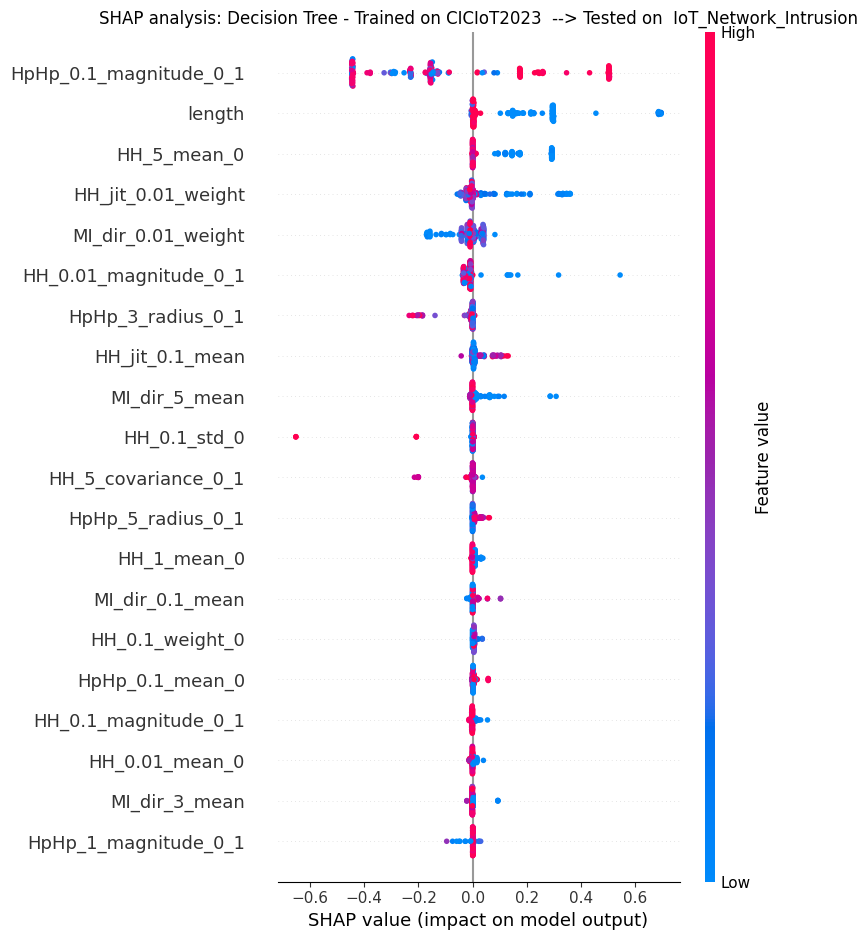


 Computing SHAP for Random Forest...


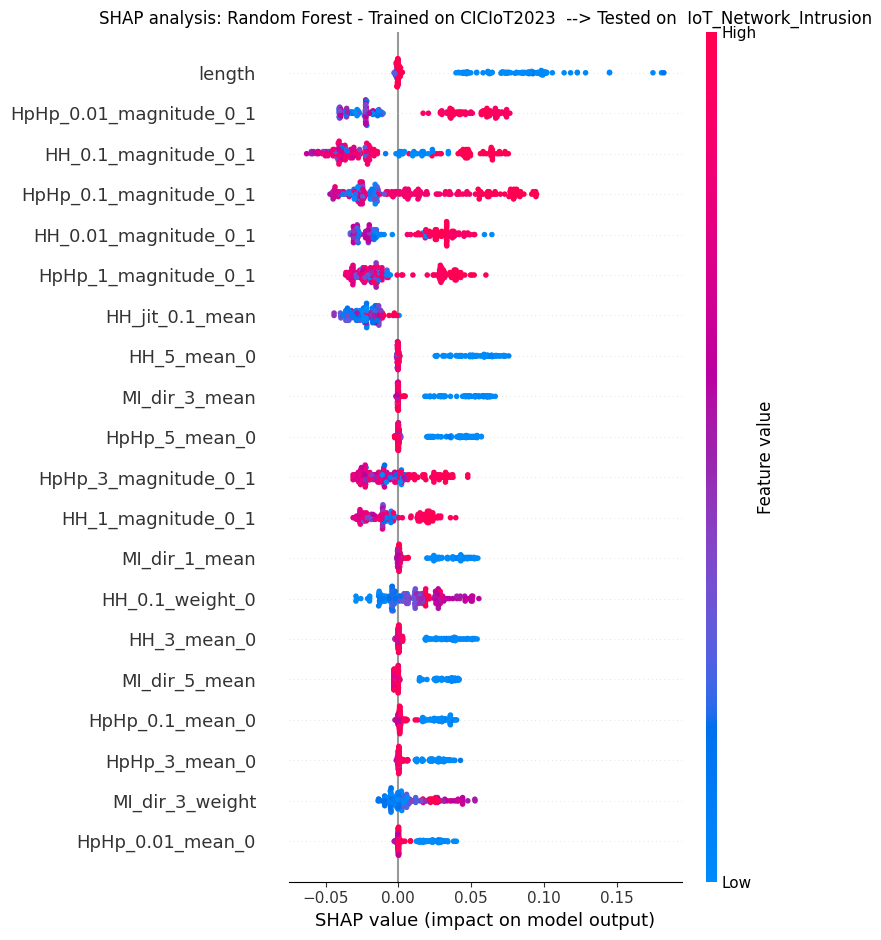


 Computing SHAP for XGBoost...


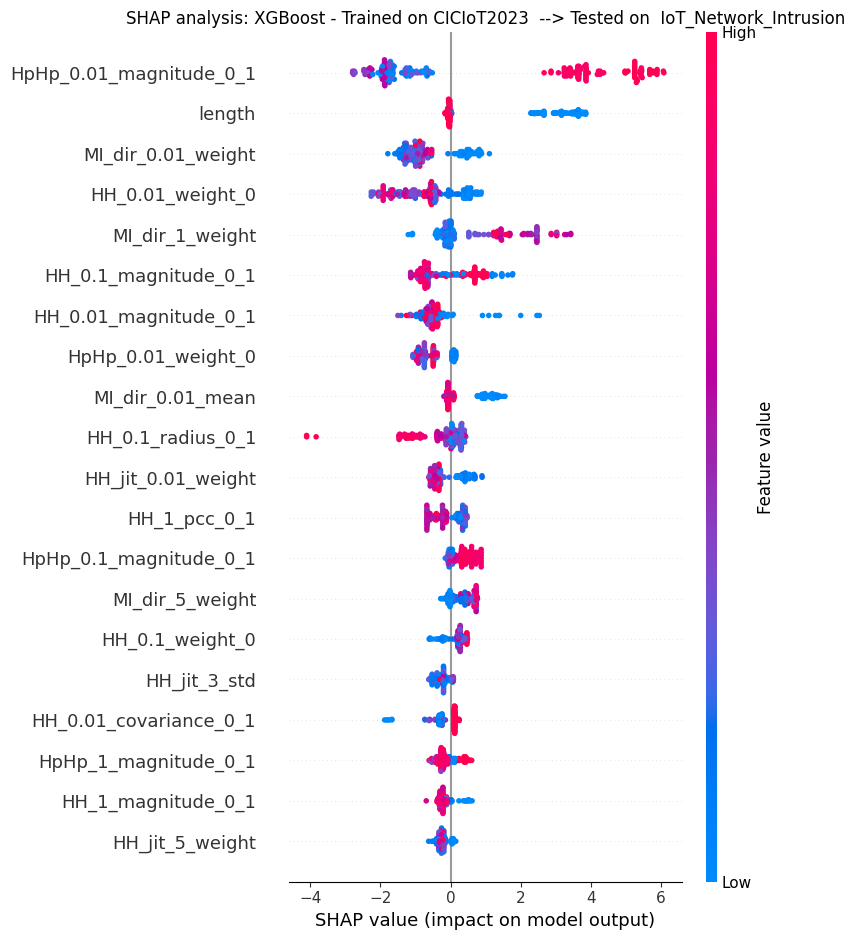

Background dataset has 32000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=32000 when initializing the masker.



 Computing SHAP values for Logistic Regression model...


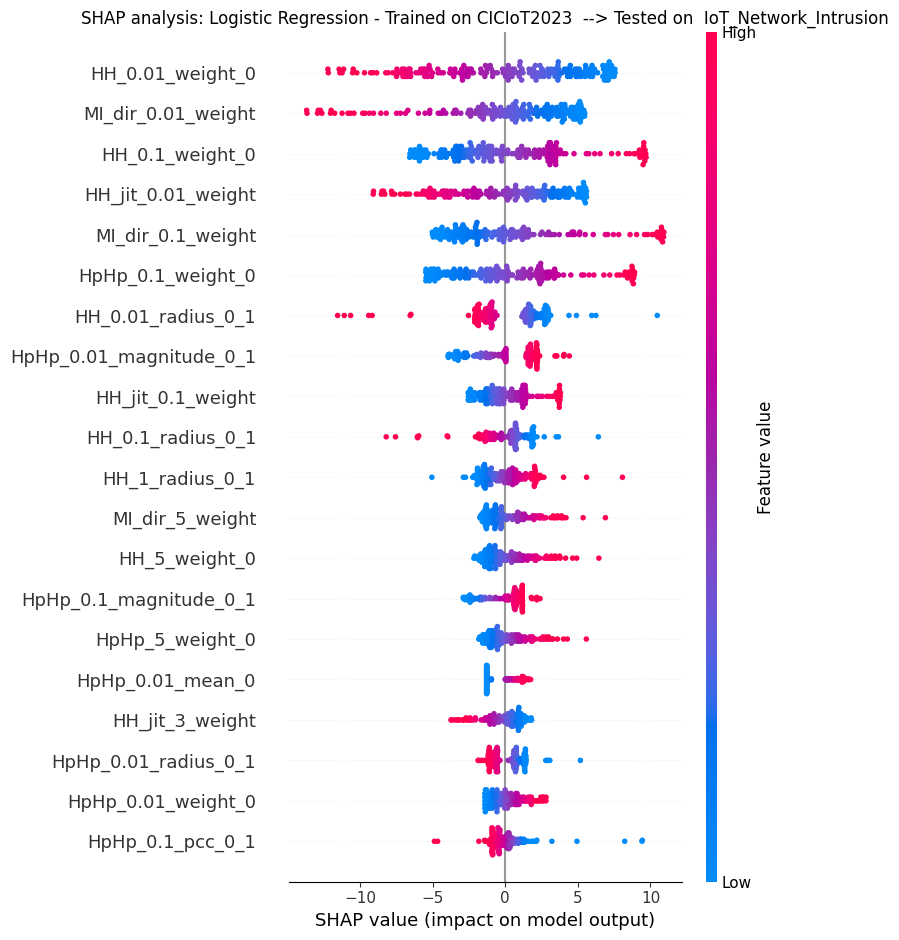


 Computing SHAP for KNN...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [03:20<00:00,  4.01s/it]


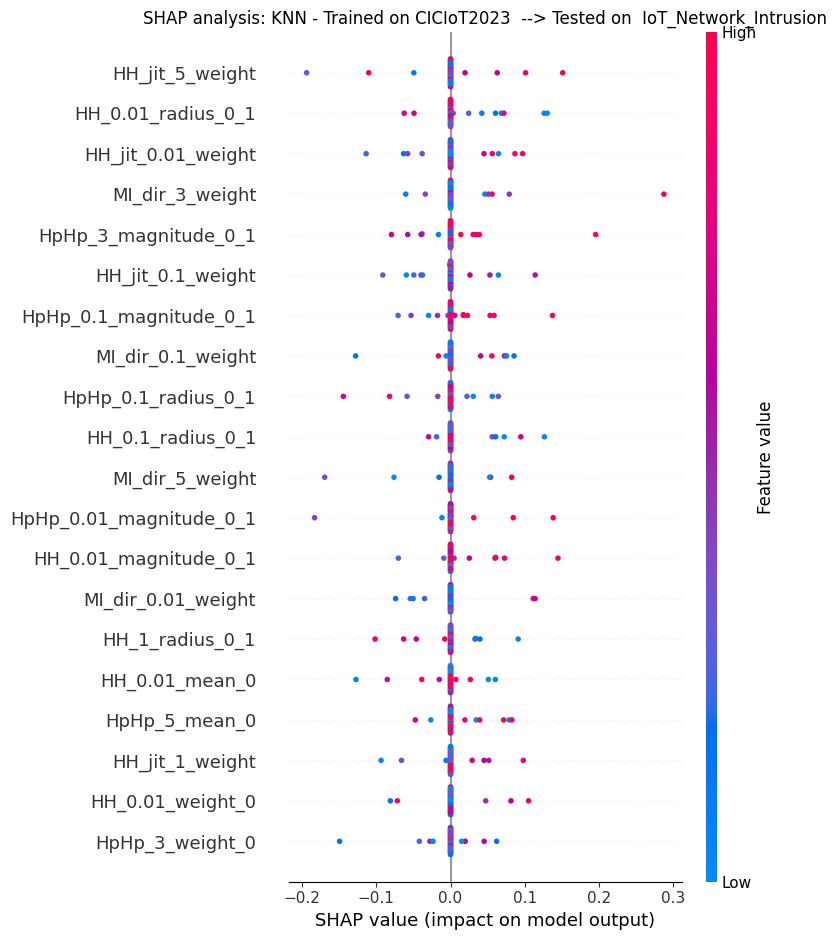


 Computing SHAP for SVM...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [08:17<00:00,  9.95s/it]


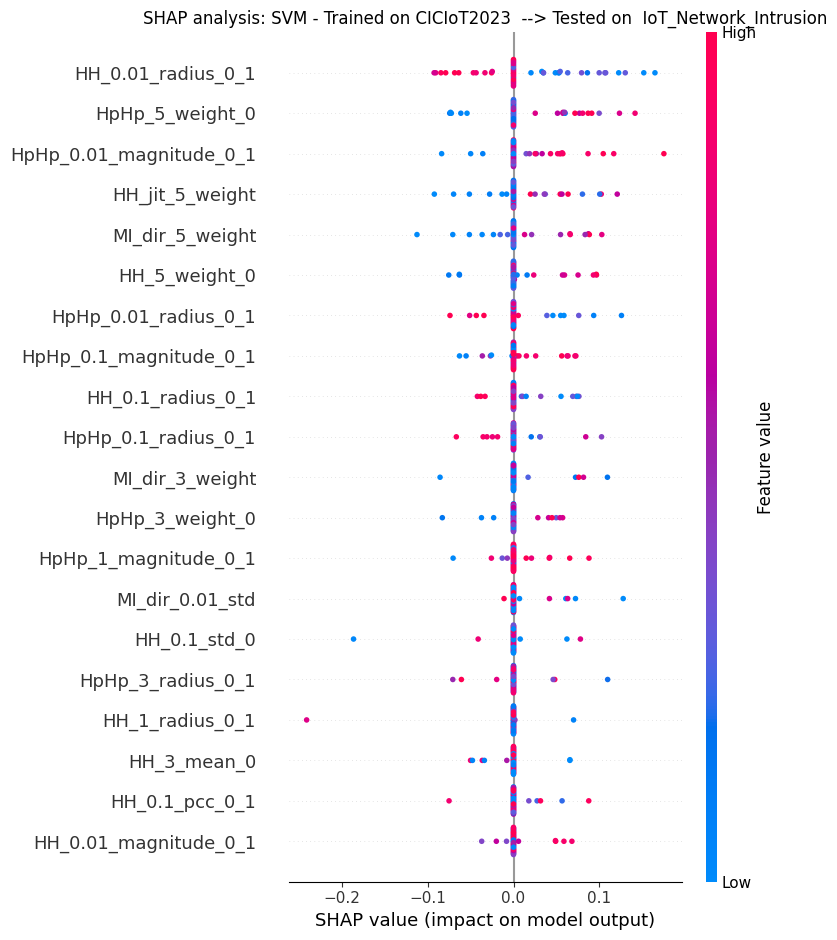

Computing SHAP values for DNN...


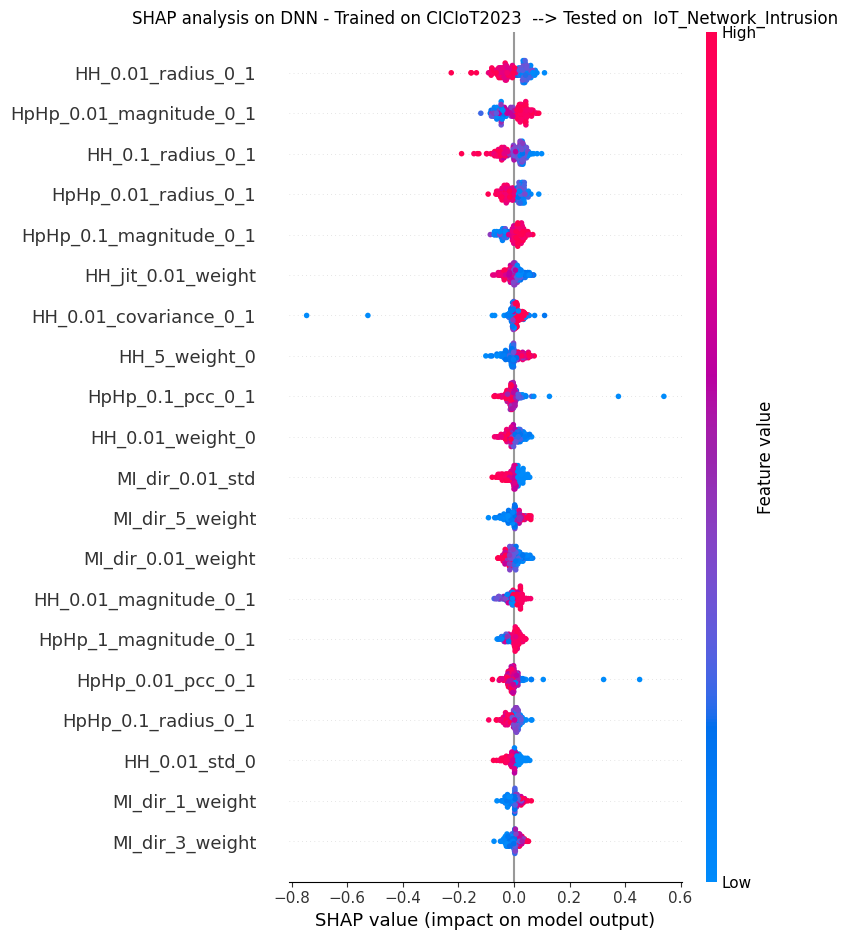


 Top 20 features across all 7 models are:

Top 10 - Decision Tree:
               Feature  Mean SHAP
HpHp_0.1_magnitude_0_1   0.284297
                length   0.149410
           HH_5_mean_0   0.089071
    HH_jit_0.01_weight   0.055596
    MI_dir_0.01_weight   0.037005
 HH_0.01_magnitude_0_1   0.023639
     HpHp_3_radius_0_1   0.017930
       HH_jit_0.1_mean   0.015420
         MI_dir_5_mean   0.015285
          HH_0.1_std_0   0.014527

Top 10 - Random Forest:
                Feature  Mean SHAP
                 length   0.042252
HpHp_0.01_magnitude_0_1   0.039085
   HH_0.1_magnitude_0_1   0.036437
 HpHp_0.1_magnitude_0_1   0.034845
  HH_0.01_magnitude_0_1   0.026842
   HpHp_1_magnitude_0_1   0.025353
        HH_jit_0.1_mean   0.022298
            HH_5_mean_0   0.021886
          MI_dir_3_mean   0.019026
          HpHp_5_mean_0   0.017493

Top 10 - XGBoost:
                Feature  Mean SHAP
HpHp_0.01_magnitude_0_1   2.990706
                 length   1.632690
     MI_dir_0.01_weight 

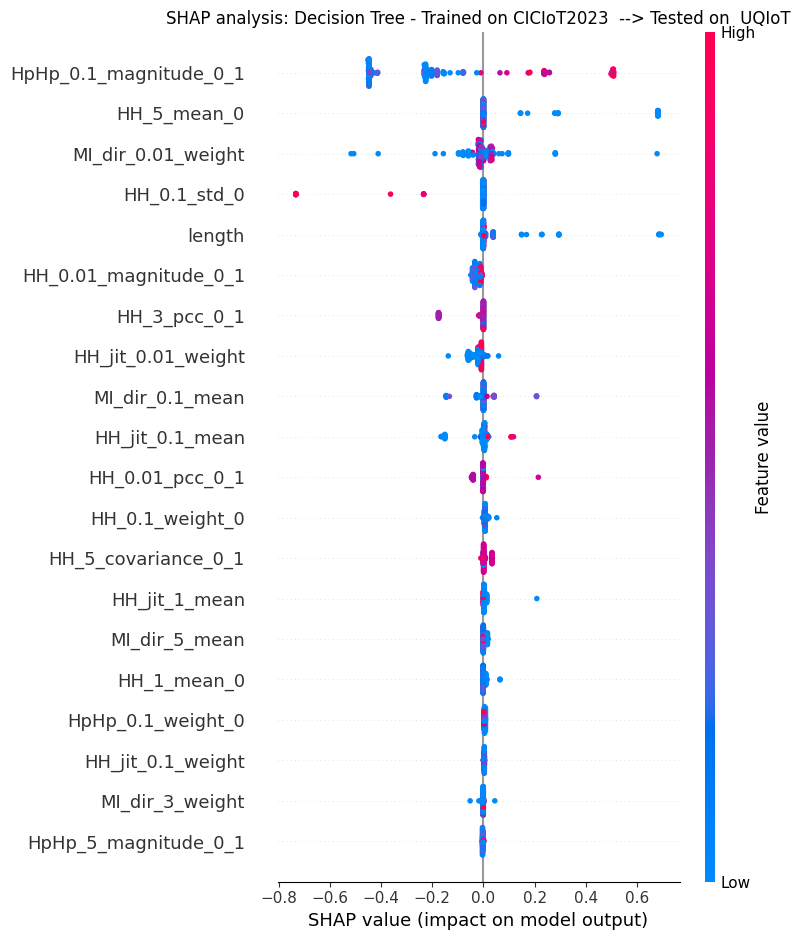


 Computing SHAP for Random Forest...


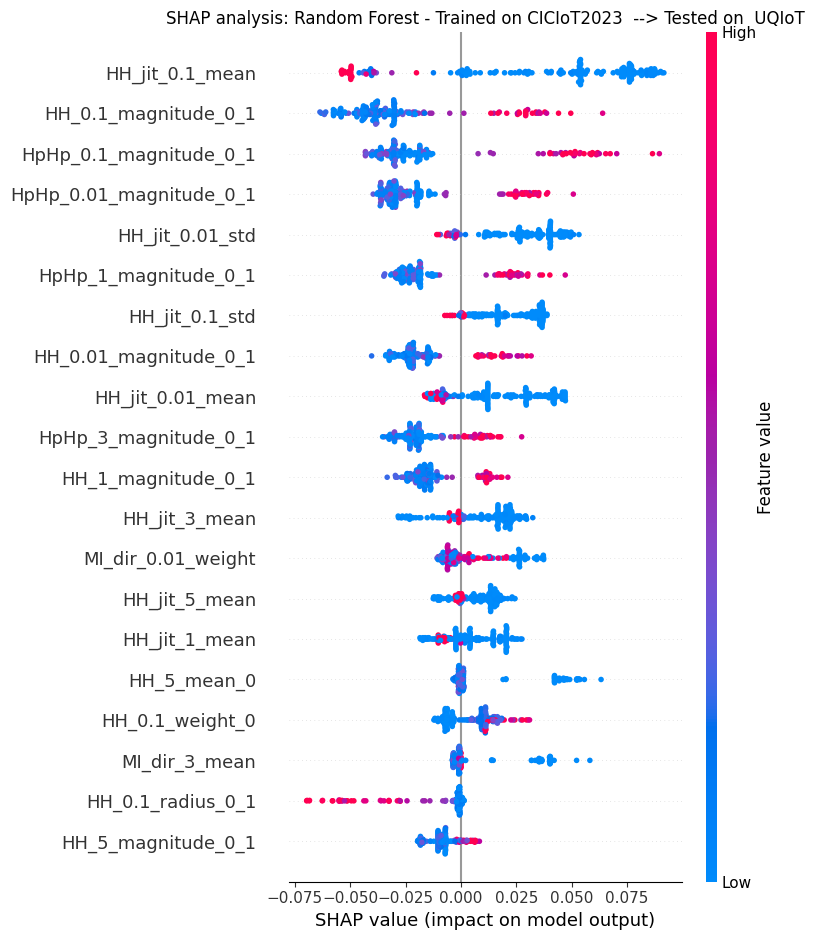


 Computing SHAP for XGBoost...


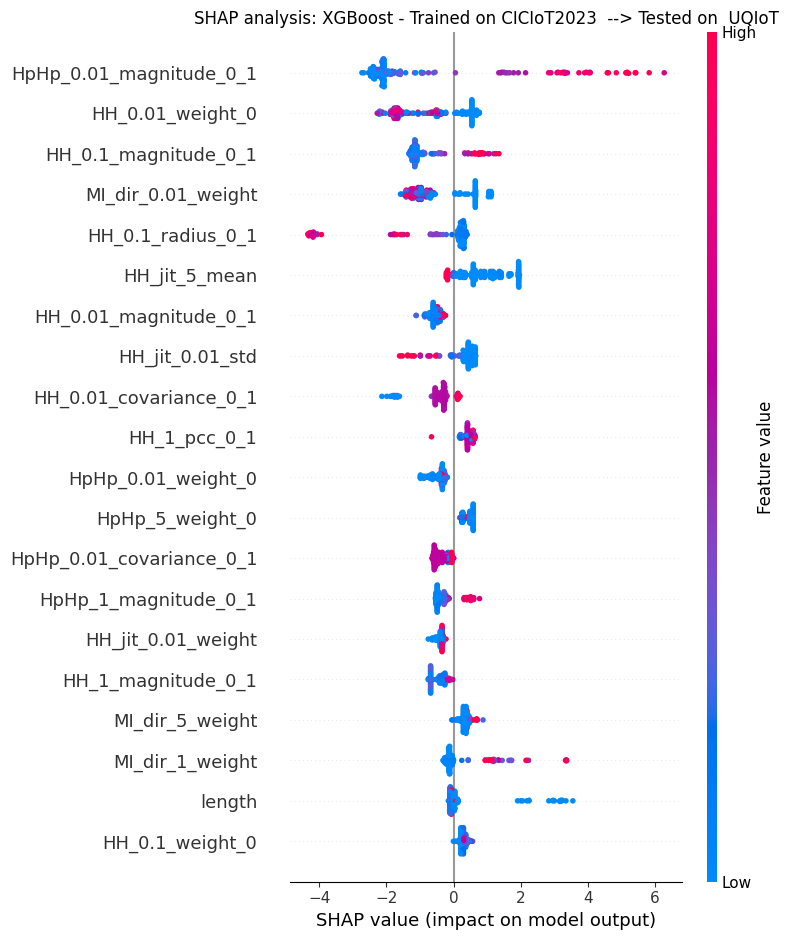

Background dataset has 32000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=32000 when initializing the masker.



 Computing SHAP values for Logistic Regression model...


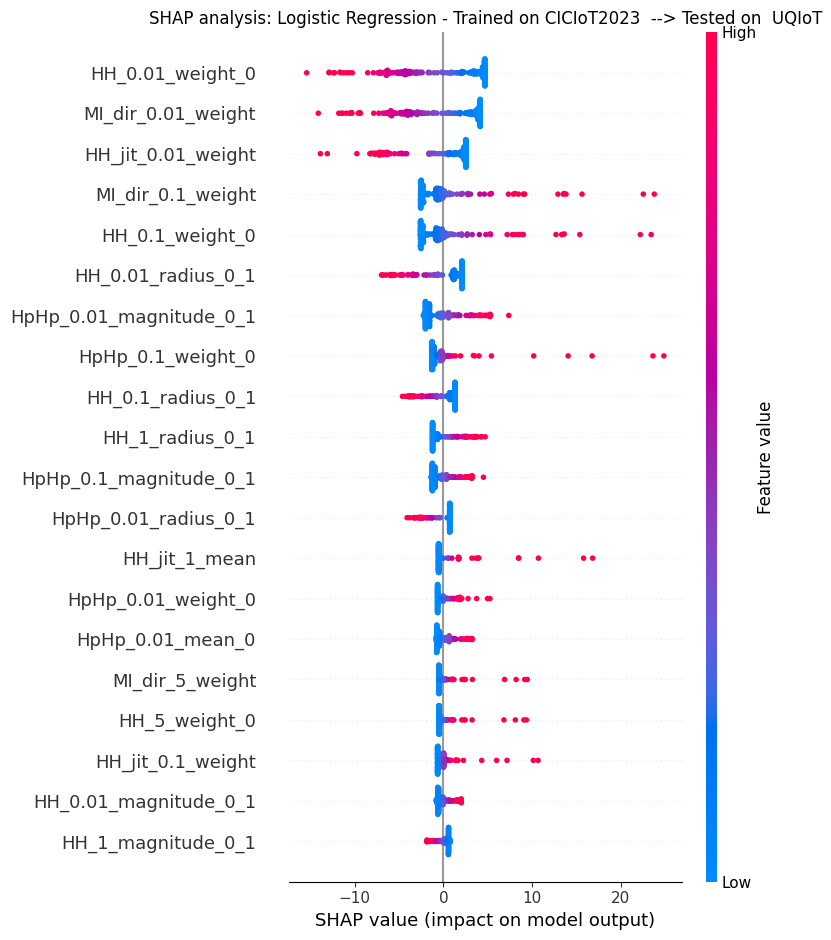


 Computing SHAP for KNN...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [03:21<00:00,  4.03s/it]


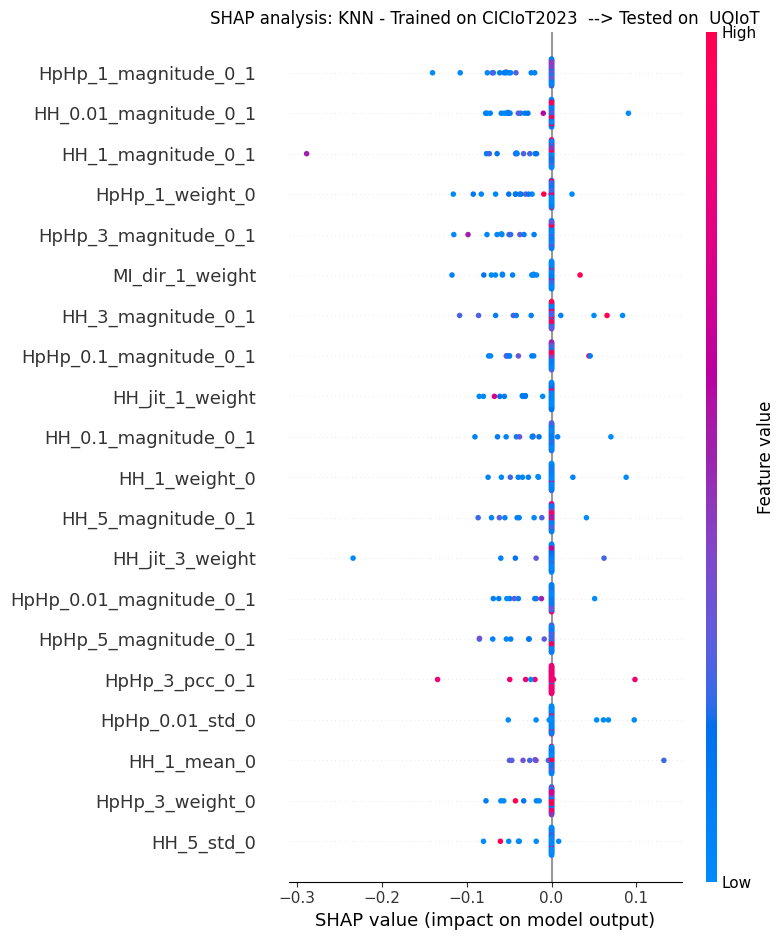


 Computing SHAP for SVM...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [08:08<00:00,  9.78s/it]


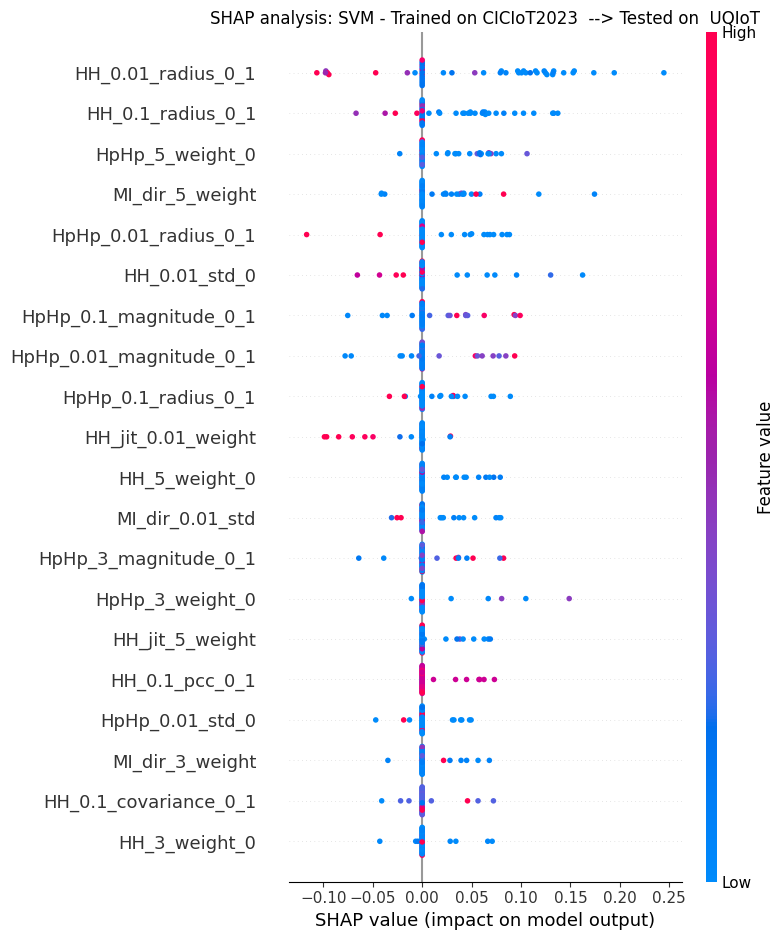

Computing SHAP values for DNN...


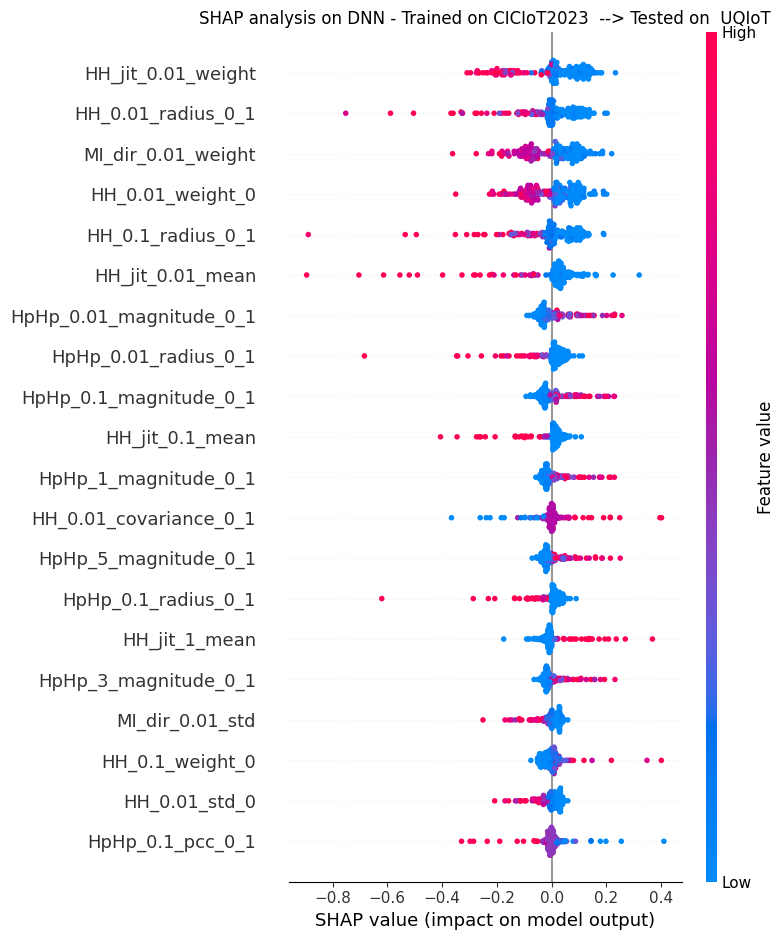


 Top 20 features across all 7 models are:

Top 10 - Decision Tree:
               Feature  Mean SHAP
HpHp_0.1_magnitude_0_1   0.320853
           HH_5_mean_0   0.119003
    MI_dir_0.01_weight   0.043836
          HH_0.1_std_0   0.041355
                length   0.040652
 HH_0.01_magnitude_0_1   0.025641
          HH_3_pcc_0_1   0.023358
    HH_jit_0.01_weight   0.022750
       MI_dir_0.1_mean   0.016950
       HH_jit_0.1_mean   0.016039

Top 10 - Random Forest:
                Feature  Mean SHAP
        HH_jit_0.1_mean   0.054046
   HH_0.1_magnitude_0_1   0.037249
 HpHp_0.1_magnitude_0_1   0.032085
HpHp_0.01_magnitude_0_1   0.028149
        HH_jit_0.01_std   0.027930
   HpHp_1_magnitude_0_1   0.023158
         HH_jit_0.1_std   0.022433
  HH_0.01_magnitude_0_1   0.021273
       HH_jit_0.01_mean   0.021208
   HpHp_3_magnitude_0_1   0.019830

Top 10 - XGBoost:
                Feature  Mean SHAP
HpHp_0.01_magnitude_0_1   2.325433
       HH_0.01_weight_0   1.103477
   HH_0.1_magnitude_0_1 

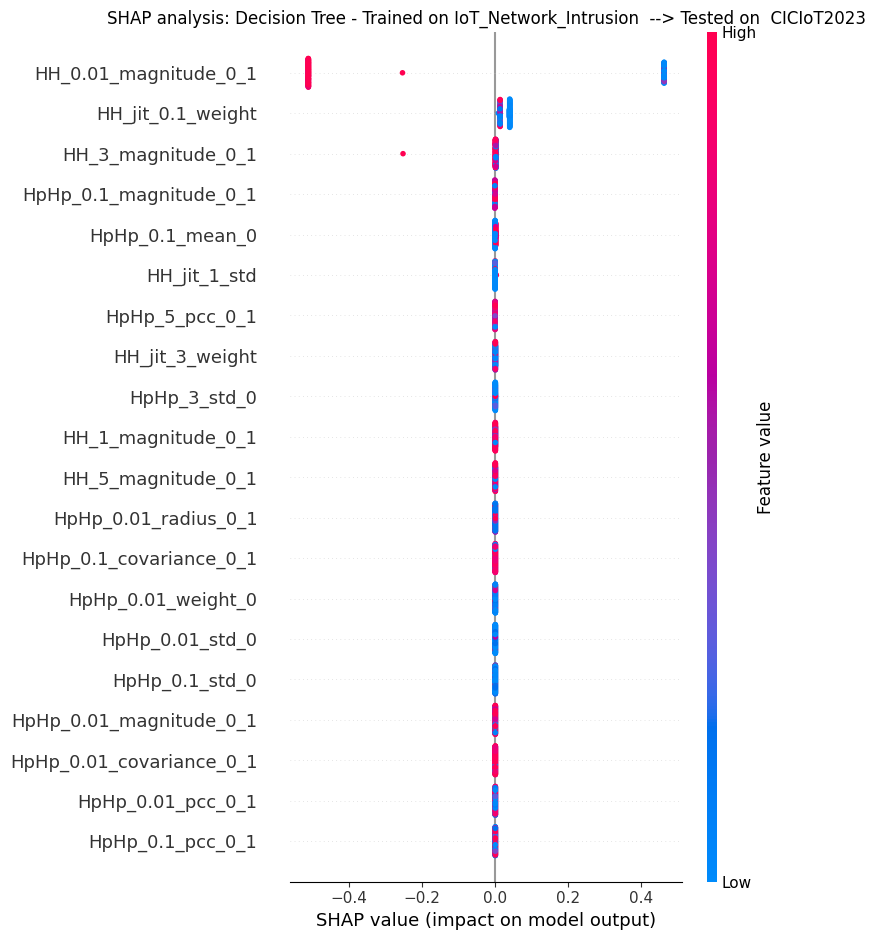


 Computing SHAP for Random Forest...


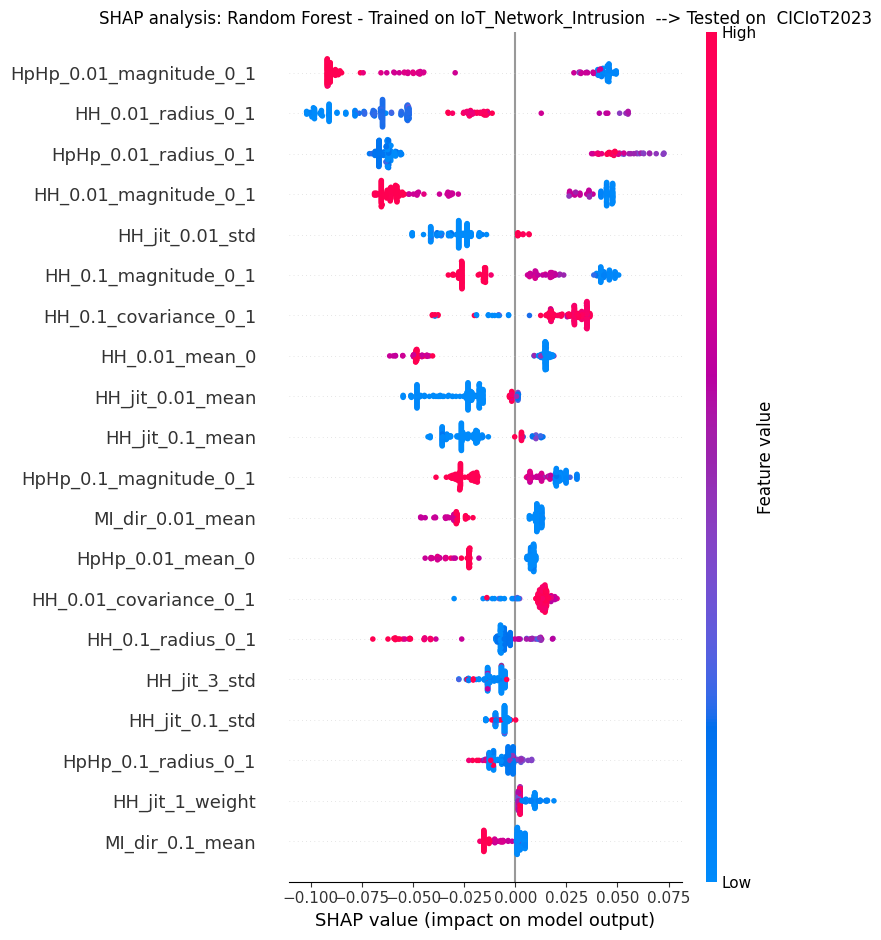


 Computing SHAP for XGBoost...


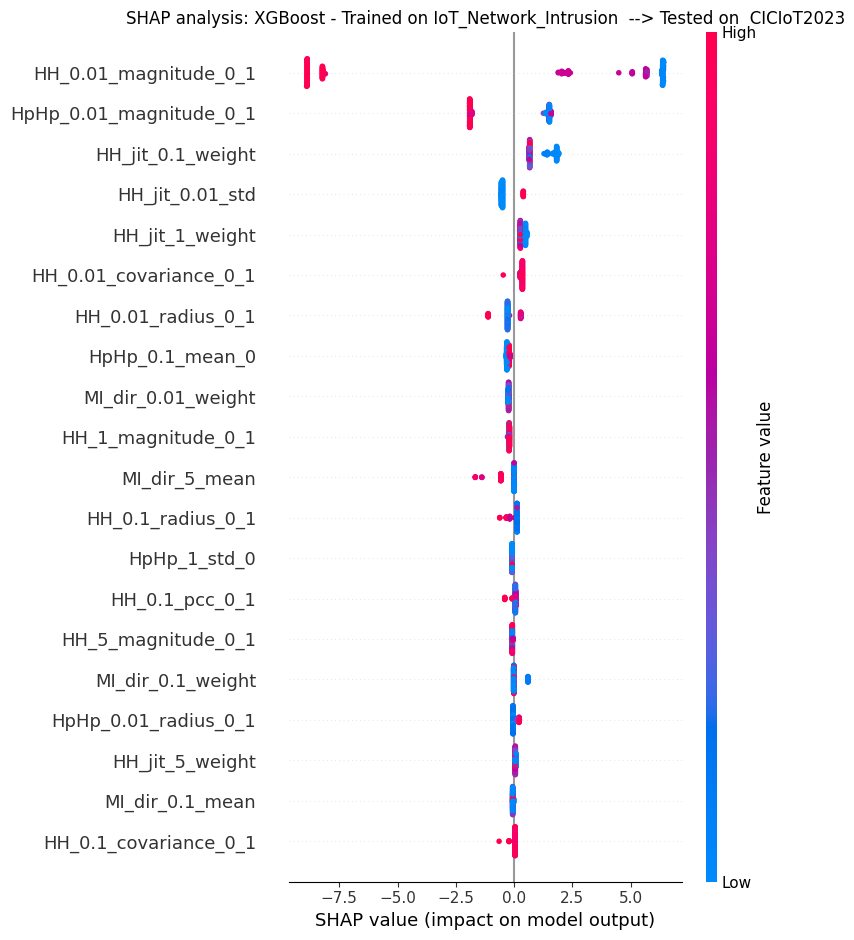

Background dataset has 32000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=32000 when initializing the masker.



 Computing SHAP values for Logistic Regression model...


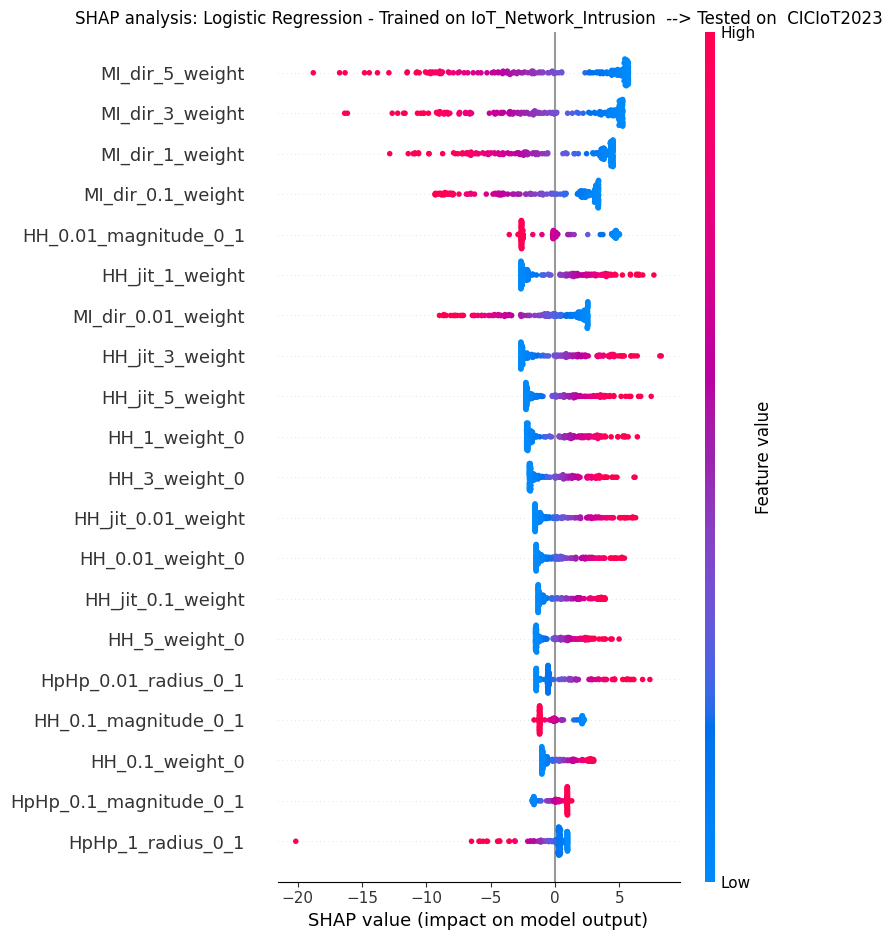


 Computing SHAP for KNN...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [03:24<00:00,  4.08s/it]


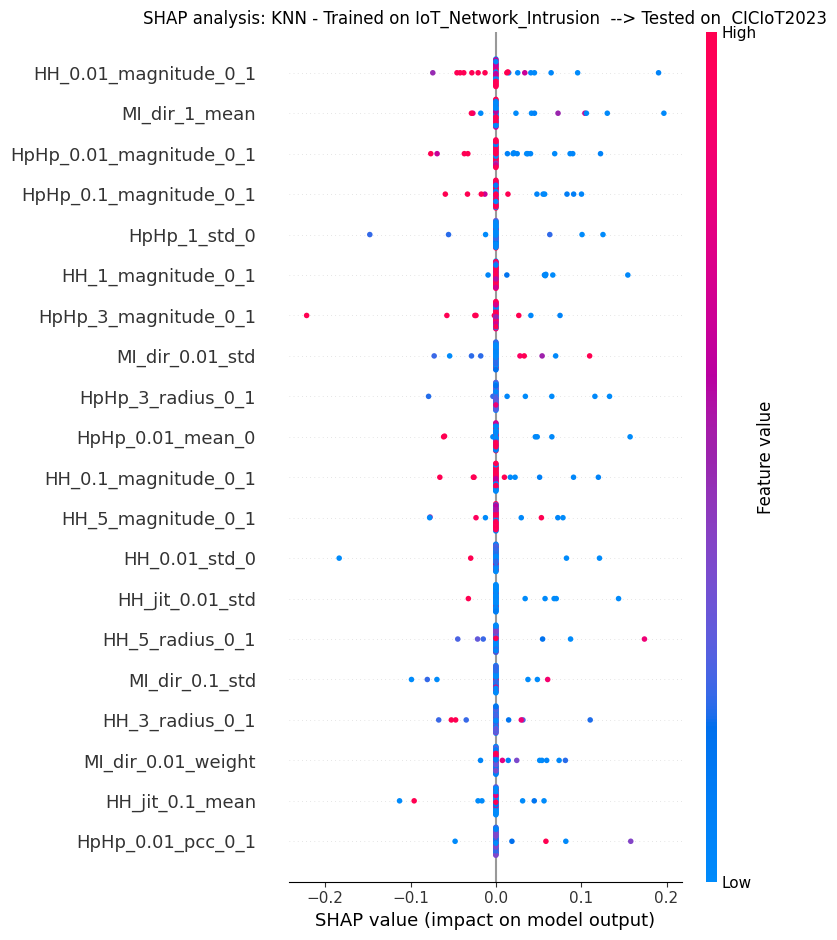


 Computing SHAP for SVM...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [01:25<00:00,  1.70s/it]


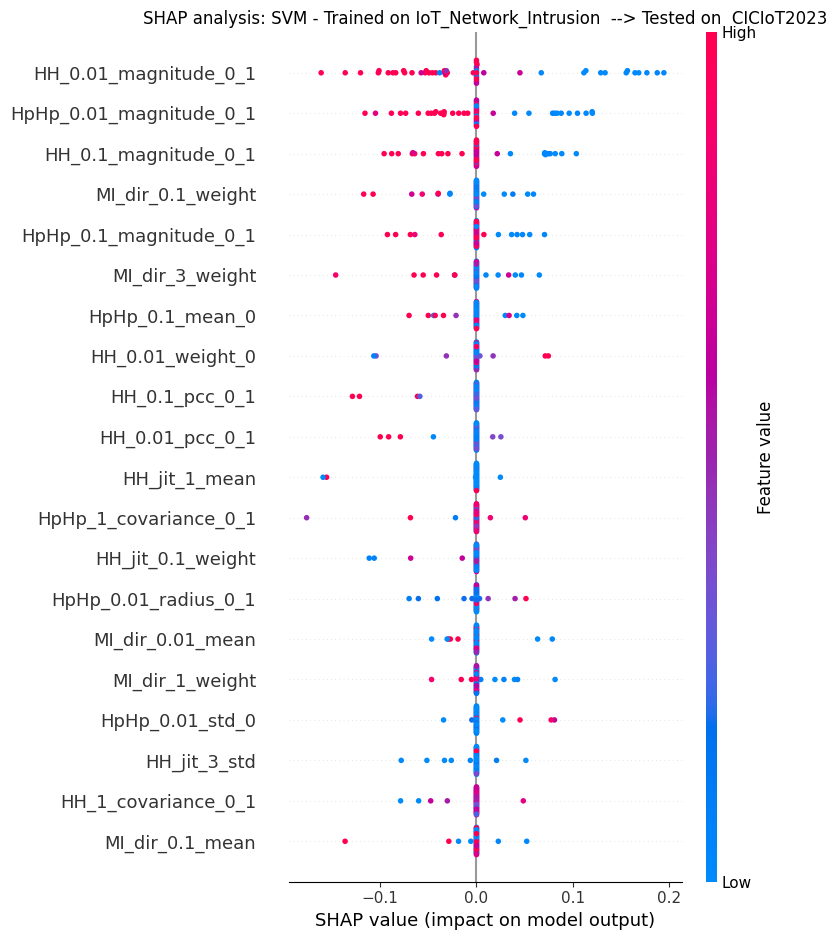

Computing SHAP values for DNN...


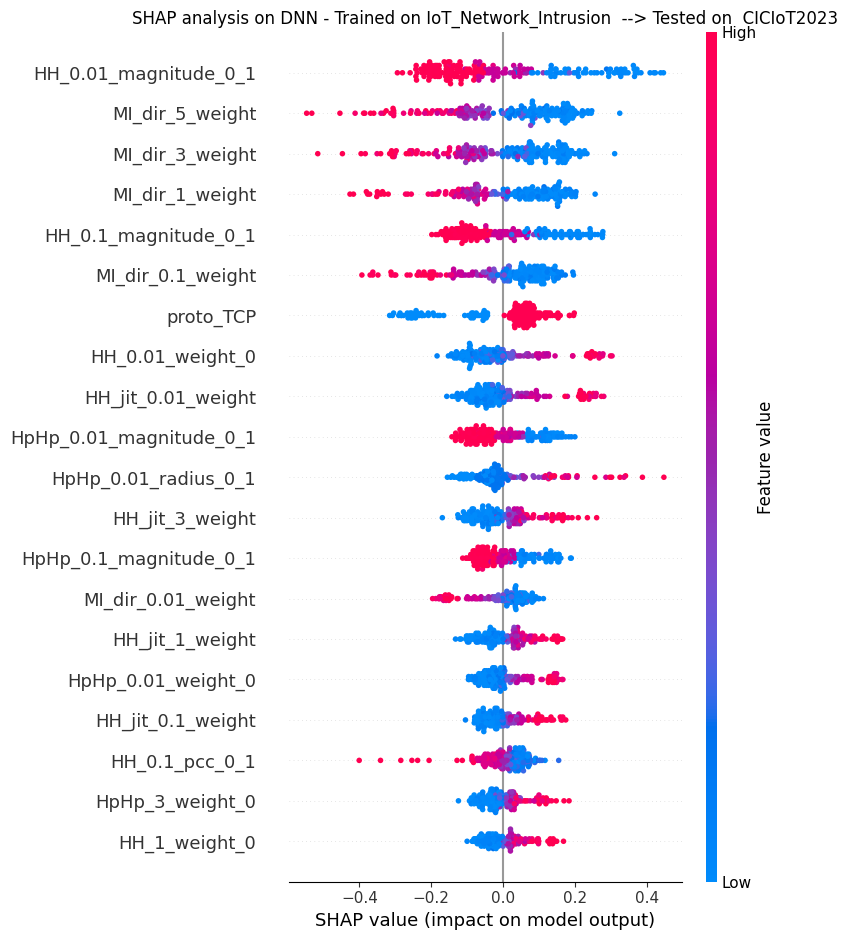


 Top 20 features across all 7 models are:

Top 10 - Decision Tree:
               Feature  Mean SHAP
 HH_0.01_magnitude_0_1   0.489815
     HH_jit_0.1_weight   0.024044
    HH_3_magnitude_0_1   0.002070
HpHp_0.1_magnitude_0_1   0.000939
       HpHp_0.1_mean_0   0.000681
          HH_jit_1_std   0.000649
        HpHp_5_pcc_0_1   0.000621
       HH_jit_3_weight   0.000069
          HpHp_3_std_0   0.000015
    HH_1_magnitude_0_1   0.000010

Top 10 - Random Forest:
                Feature  Mean SHAP
HpHp_0.01_magnitude_0_1   0.066537
     HH_0.01_radius_0_1   0.062523
   HpHp_0.01_radius_0_1   0.061076
  HH_0.01_magnitude_0_1   0.050911
        HH_jit_0.01_std   0.027992
   HH_0.1_magnitude_0_1   0.026770
  HH_0.1_covariance_0_1   0.026761
         HH_0.01_mean_0   0.025628
       HH_jit_0.01_mean   0.024311
        HH_jit_0.1_mean   0.023187

Top 10 - XGBoost:
                Feature  Mean SHAP
  HH_0.01_magnitude_0_1   6.924626
HpHp_0.01_magnitude_0_1   1.720654
      HH_jit_0.1_weight 

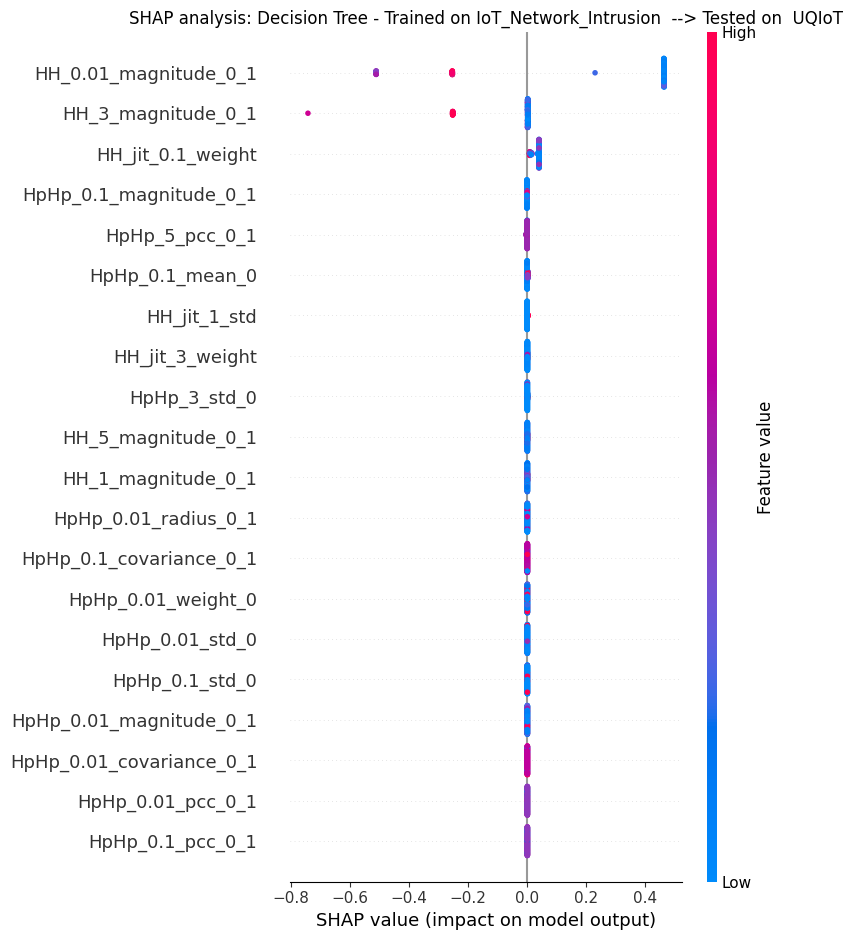


 Computing SHAP for Random Forest...


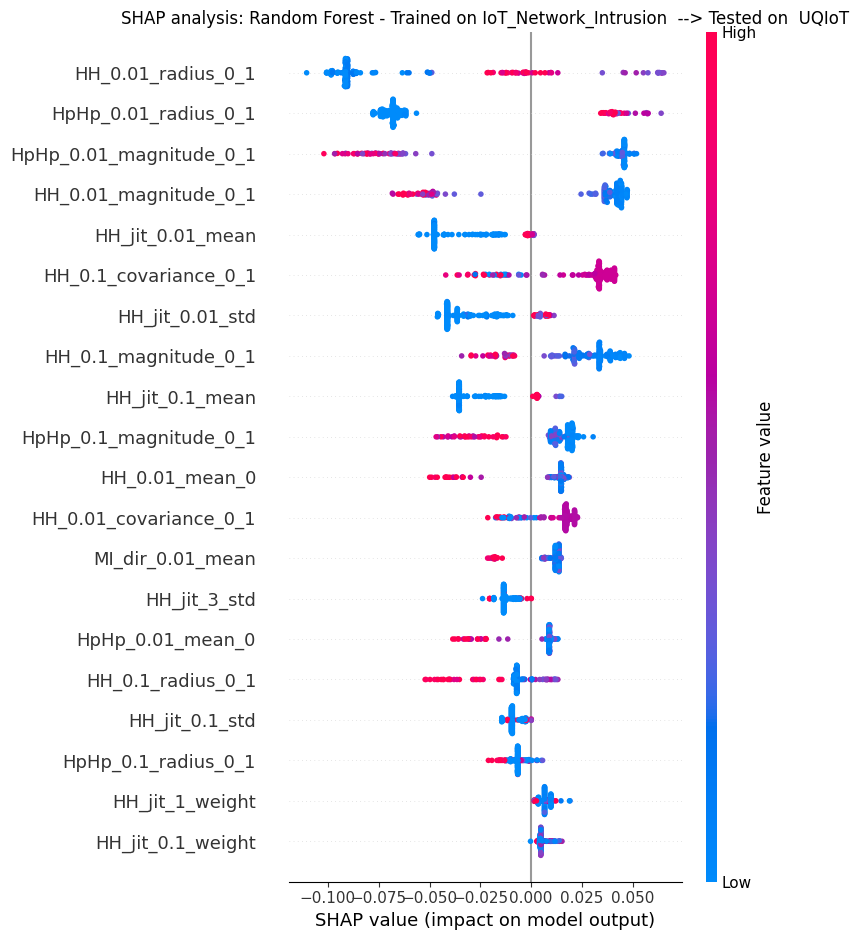


 Computing SHAP for XGBoost...


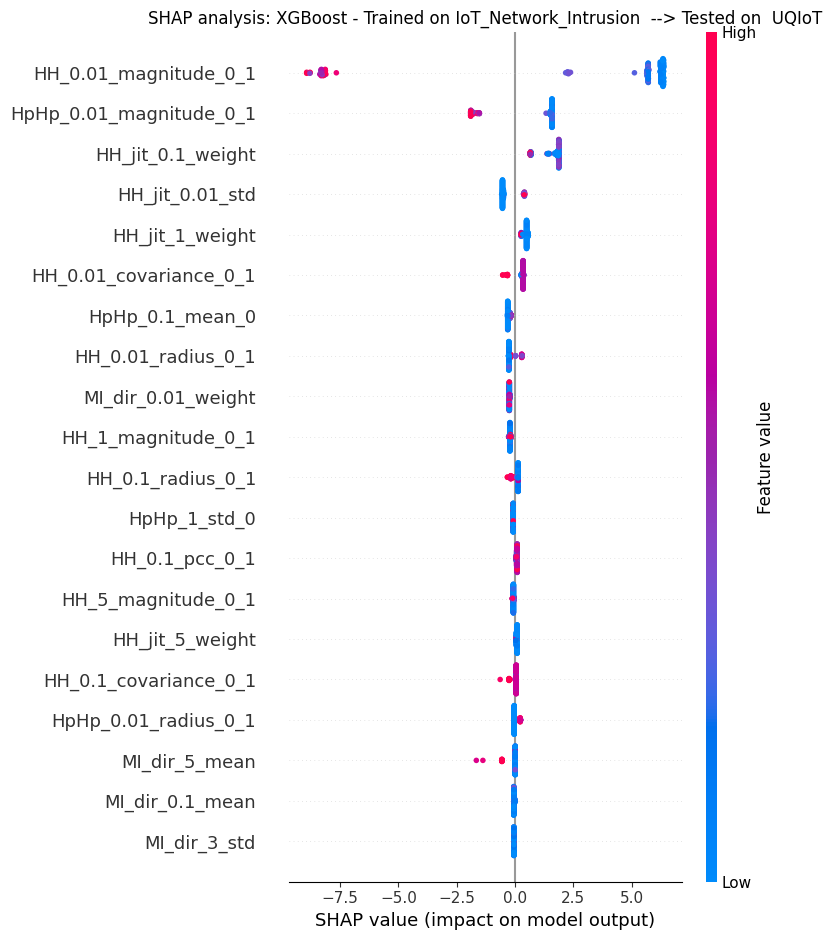

Background dataset has 32000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=32000 when initializing the masker.



 Computing SHAP values for Logistic Regression model...


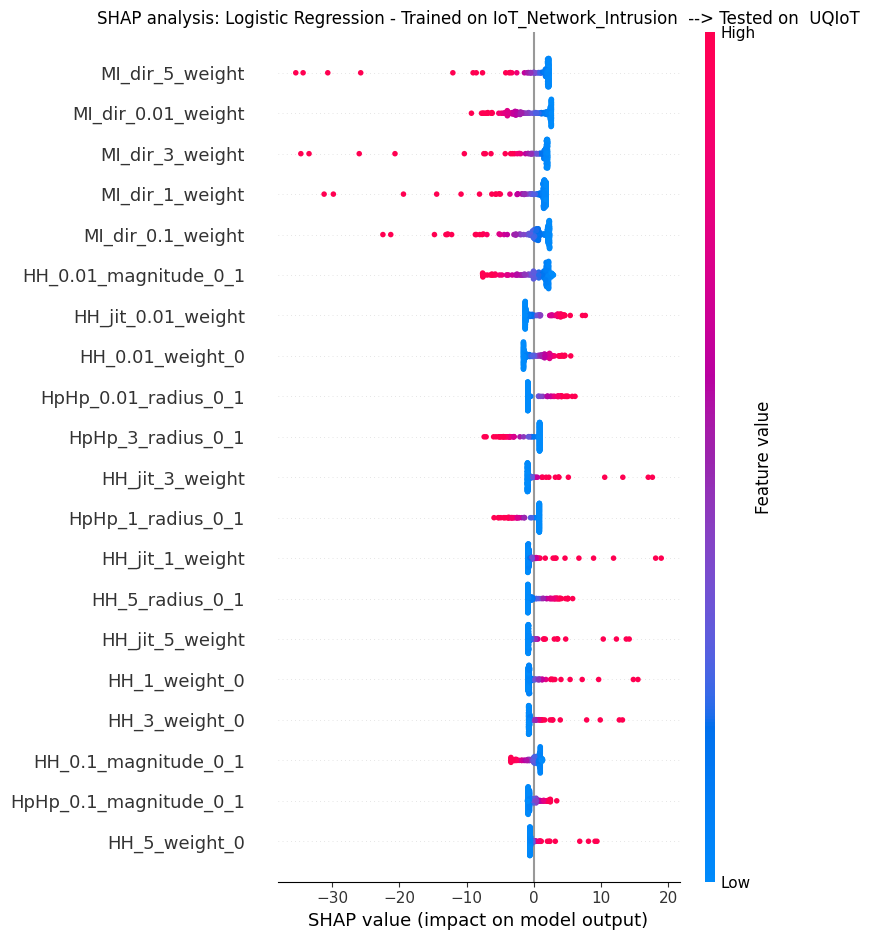


 Computing SHAP for KNN...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [03:21<00:00,  4.03s/it]


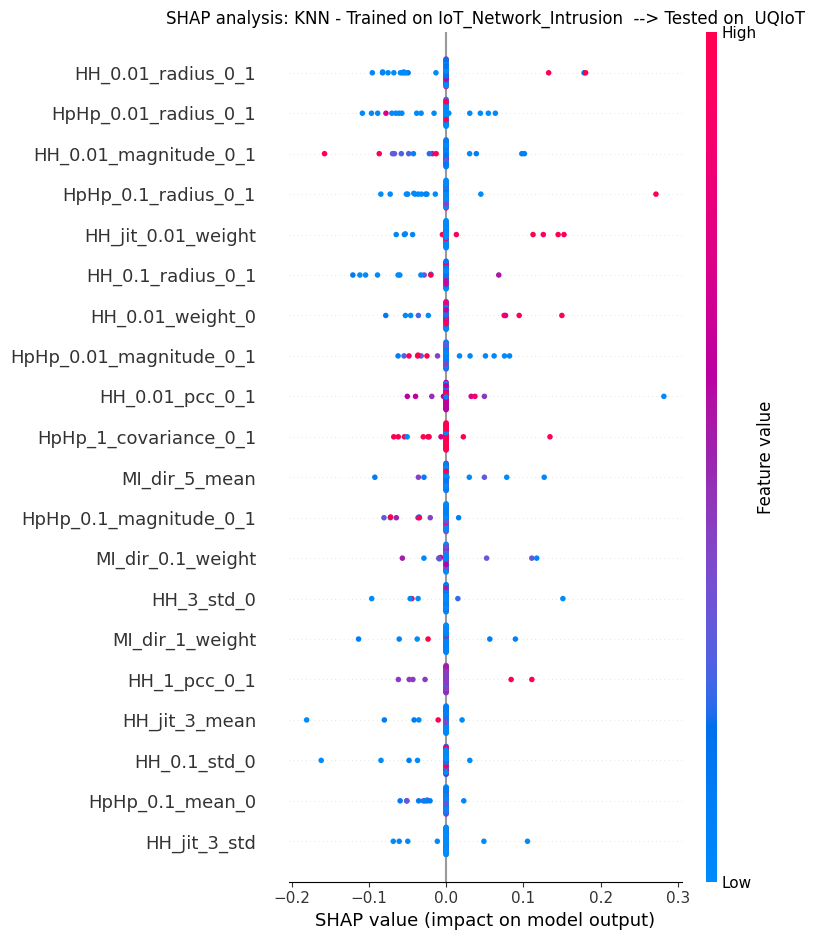


 Computing SHAP for SVM...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [01:25<00:00,  1.71s/it]


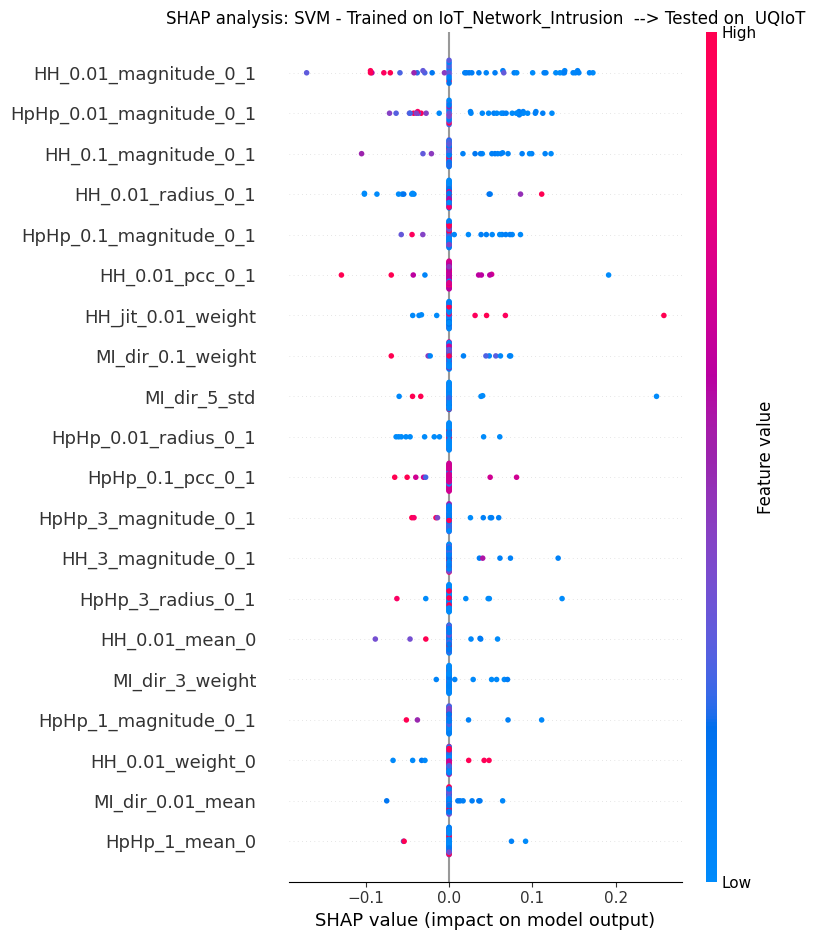

Computing SHAP values for DNN...


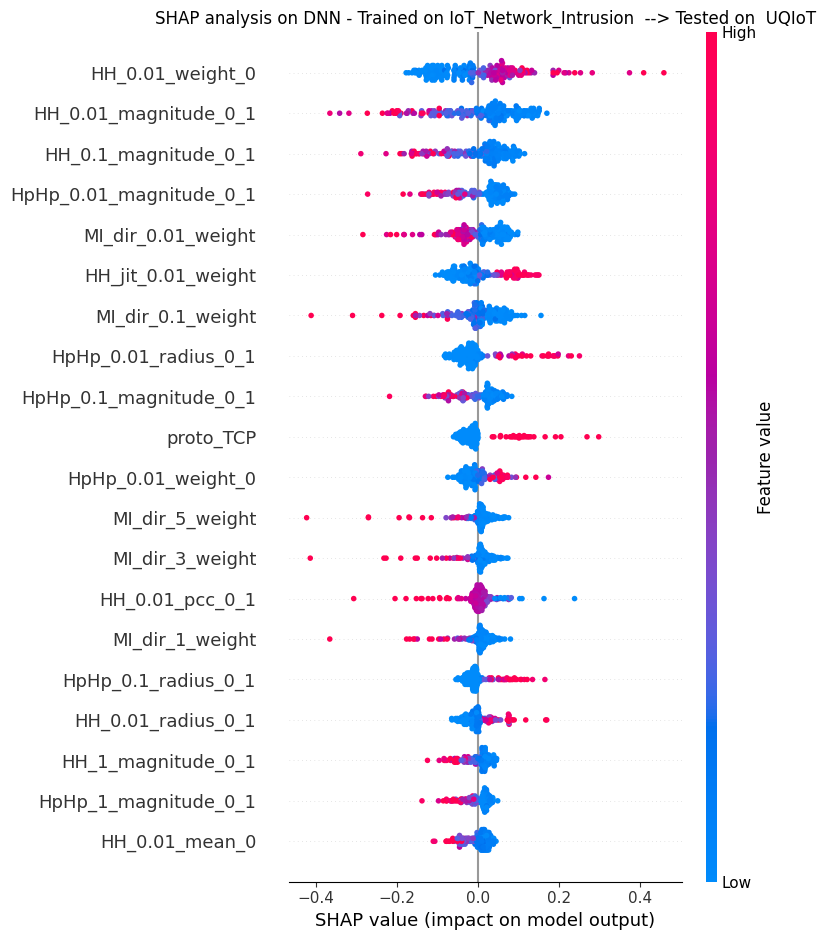


 Top 20 features across all 7 models are:

Top 10 - Decision Tree:
               Feature  Mean SHAP
 HH_0.01_magnitude_0_1   0.442207
    HH_3_magnitude_0_1   0.033846
     HH_jit_0.1_weight   0.032892
HpHp_0.1_magnitude_0_1   0.001178
        HpHp_5_pcc_0_1   0.000803
       HpHp_0.1_mean_0   0.000801
          HH_jit_1_std   0.000792
       HH_jit_3_weight   0.000082
          HpHp_3_std_0   0.000021
    HH_5_magnitude_0_1   0.000012

Top 10 - Random Forest:
                Feature  Mean SHAP
     HH_0.01_radius_0_1   0.073910
   HpHp_0.01_radius_0_1   0.063963
HpHp_0.01_magnitude_0_1   0.053379
  HH_0.01_magnitude_0_1   0.043624
       HH_jit_0.01_mean   0.034971
  HH_0.1_covariance_0_1   0.031709
        HH_jit_0.01_std   0.030708
   HH_0.1_magnitude_0_1   0.028849
        HH_jit_0.1_mean   0.027381
 HpHp_0.1_magnitude_0_1   0.018397

Top 10 - XGBoost:
                Feature  Mean SHAP
  HH_0.01_magnitude_0_1   6.327300
HpHp_0.01_magnitude_0_1   1.631509
      HH_jit_0.1_weight 

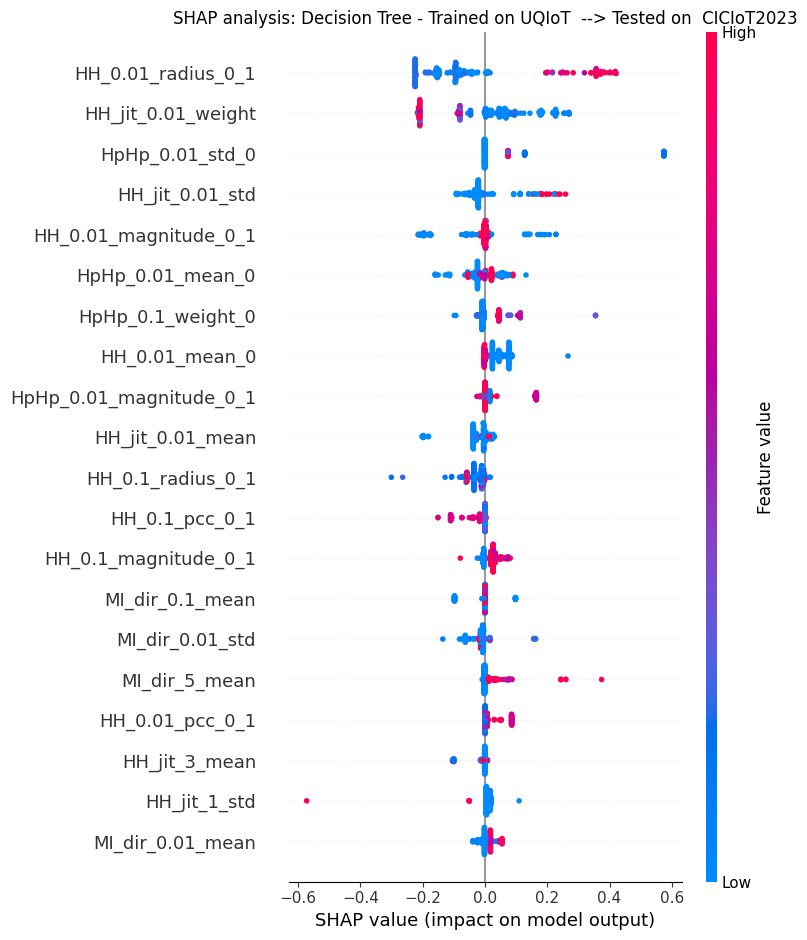


 Computing SHAP for Random Forest...


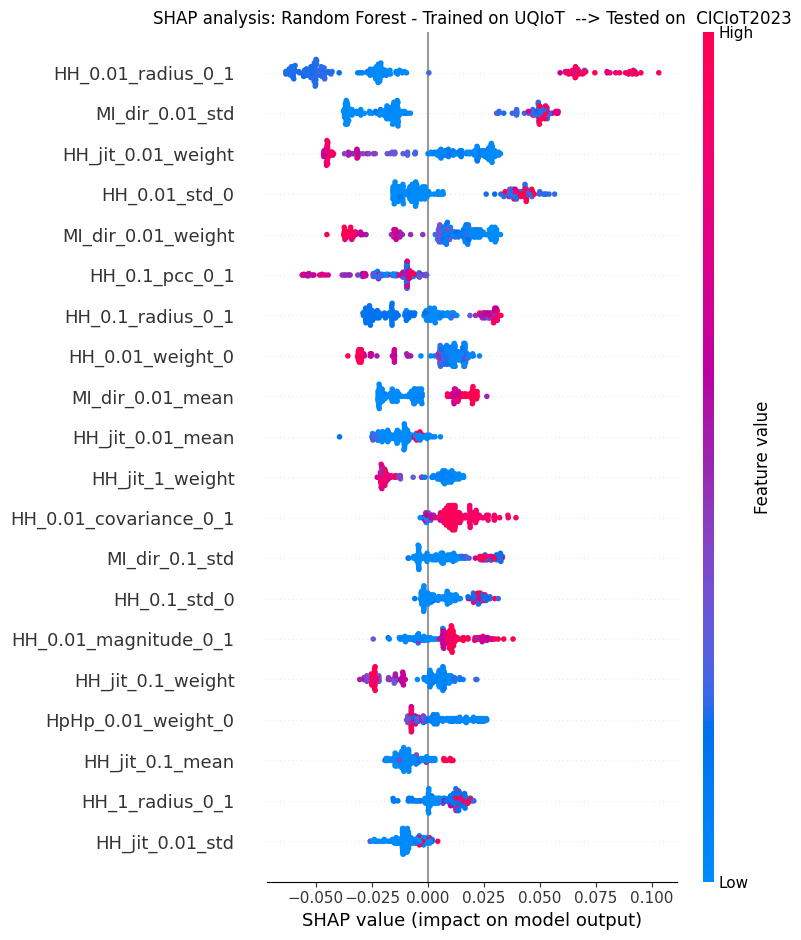


 Computing SHAP for XGBoost...


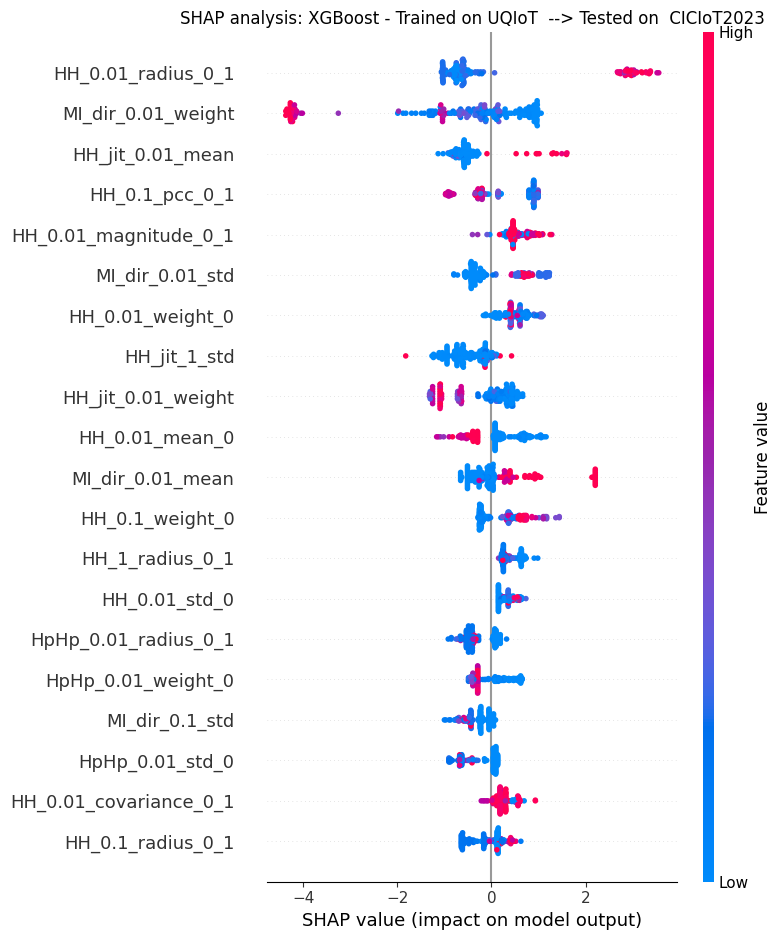

Background dataset has 24482 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=24482 when initializing the masker.



 Computing SHAP values for Logistic Regression model...


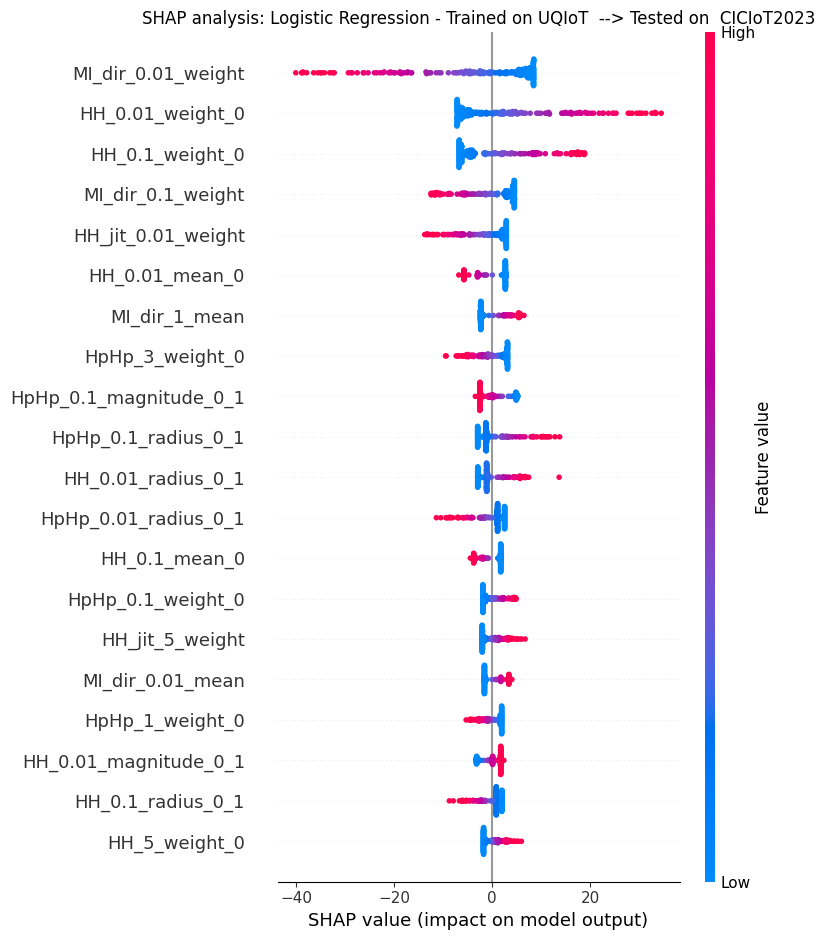


 Computing SHAP for KNN...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [02:34<00:00,  3.10s/it]


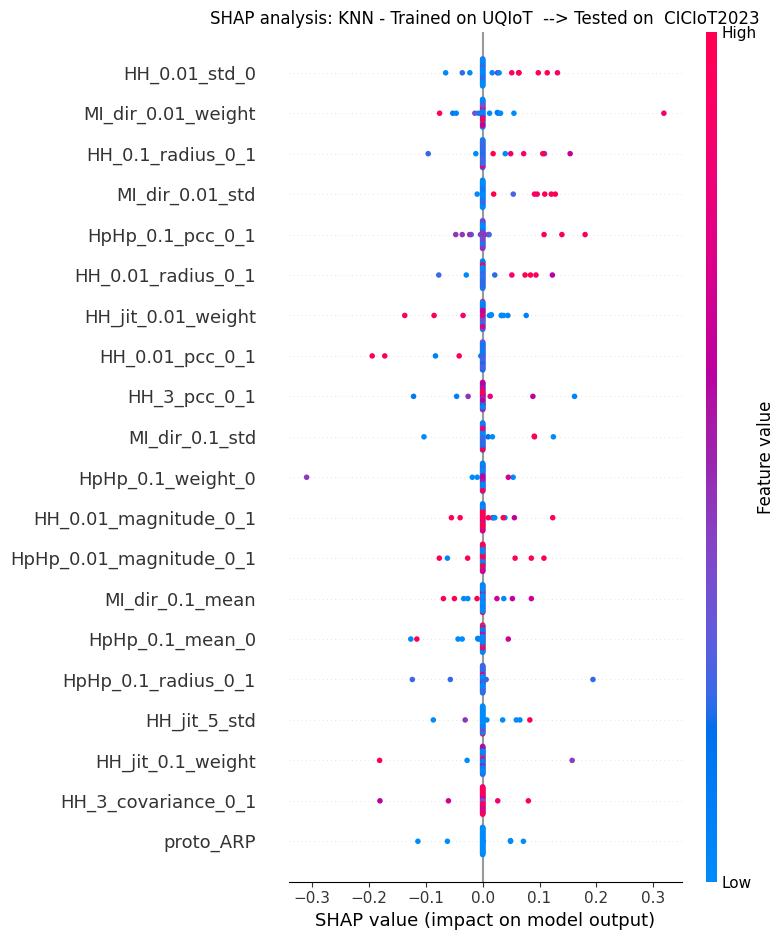


 Computing SHAP for SVM...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [30:19<00:00, 36.39s/it]


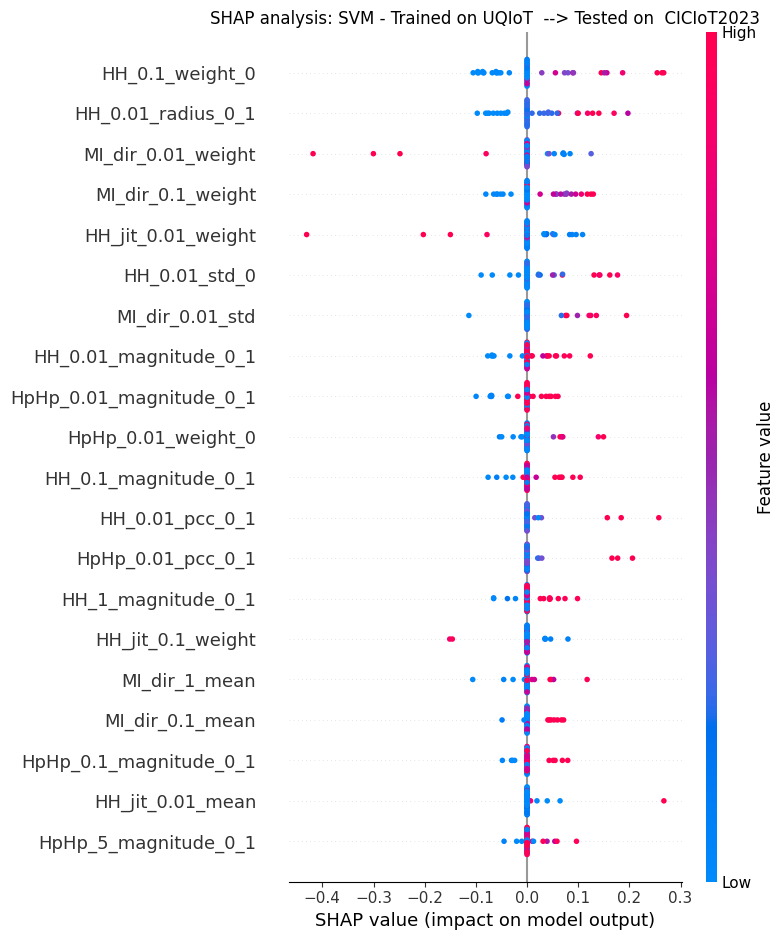

Computing SHAP values for DNN...


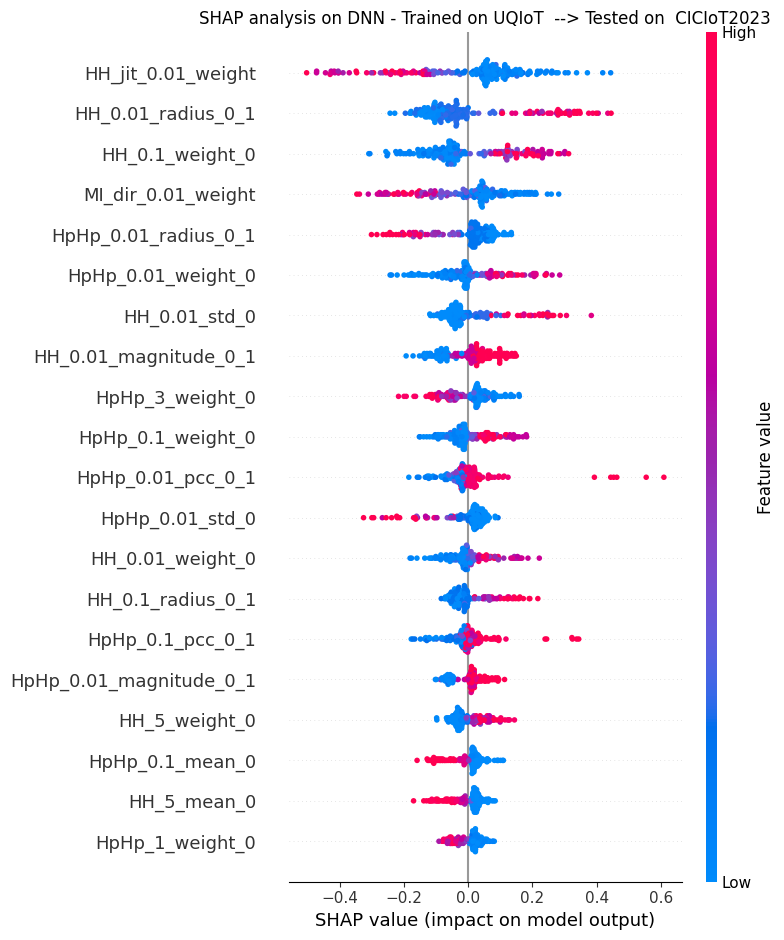


 Top 20 features across all 7 models are:

Top 10 - Decision Tree:
                Feature  Mean SHAP
     HH_0.01_radius_0_1   0.182243
     HH_jit_0.01_weight   0.111372
        HpHp_0.01_std_0   0.086604
        HH_jit_0.01_std   0.046789
  HH_0.01_magnitude_0_1   0.043811
       HpHp_0.01_mean_0   0.036341
      HpHp_0.1_weight_0   0.035744
         HH_0.01_mean_0   0.035686
HpHp_0.01_magnitude_0_1   0.031598
       HH_jit_0.01_mean   0.028566

Top 10 - Random Forest:
           Feature  Mean SHAP
HH_0.01_radius_0_1   0.047796
   MI_dir_0.01_std   0.031652
HH_jit_0.01_weight   0.023532
     HH_0.01_std_0   0.019342
MI_dir_0.01_weight   0.018586
    HH_0.1_pcc_0_1   0.017745
 HH_0.1_radius_0_1   0.016804
  HH_0.01_weight_0   0.014147
  MI_dir_0.01_mean   0.013338
  HH_jit_0.01_mean   0.013242

Top 10 - XGBoost:
              Feature  Mean SHAP
   HH_0.01_radius_0_1   1.237278
   MI_dir_0.01_weight   1.228596
     HH_jit_0.01_mean   0.630666
       HH_0.1_pcc_0_1   0.591082
HH_0.01_

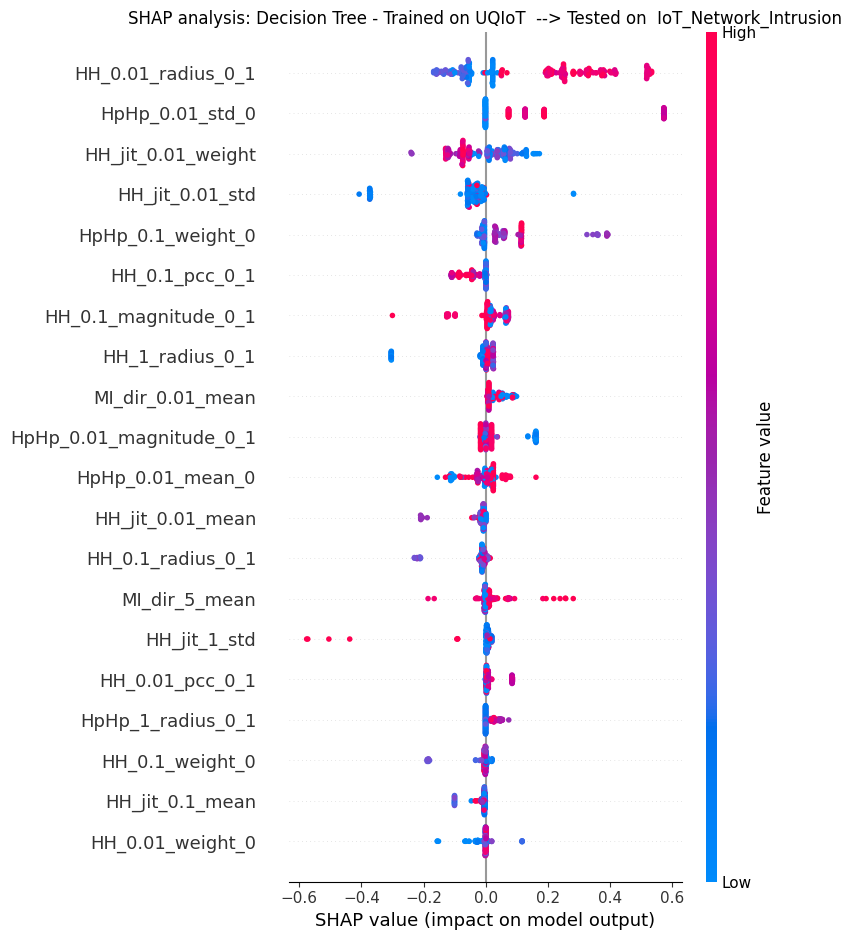


 Computing SHAP for Random Forest...


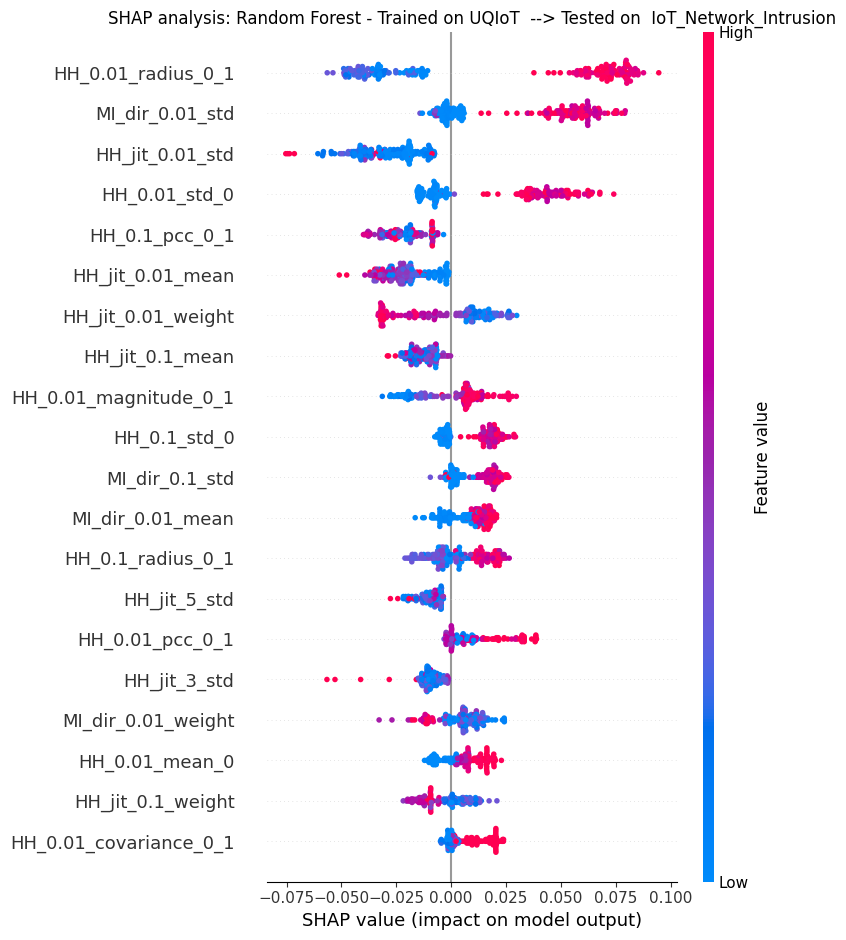


 Computing SHAP for XGBoost...


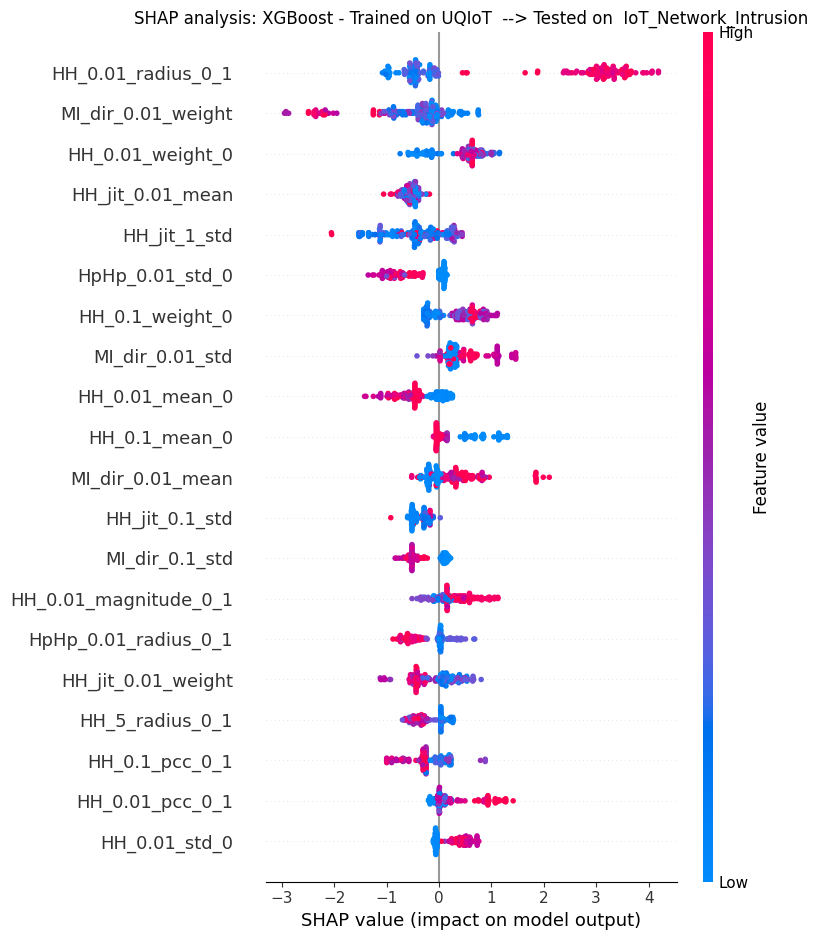

Background dataset has 24482 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=24482 when initializing the masker.



 Computing SHAP values for Logistic Regression model...


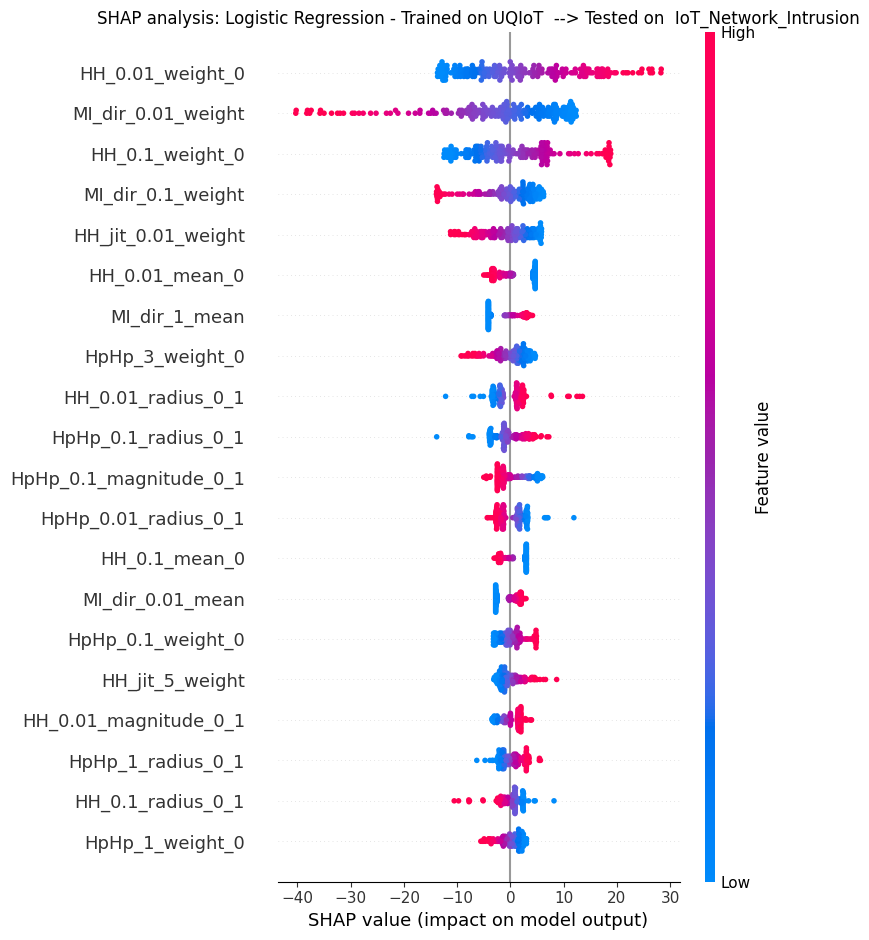


 Computing SHAP for KNN...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [02:40<00:00,  3.21s/it]


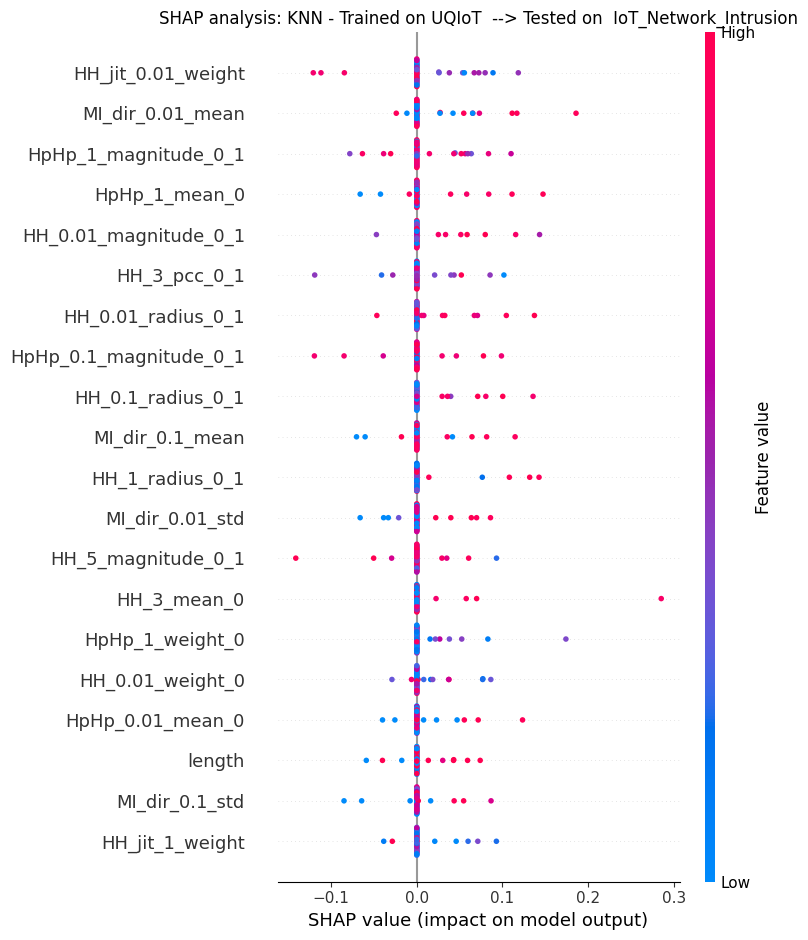


 Computing SHAP for SVM...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [30:05<00:00, 36.12s/it]


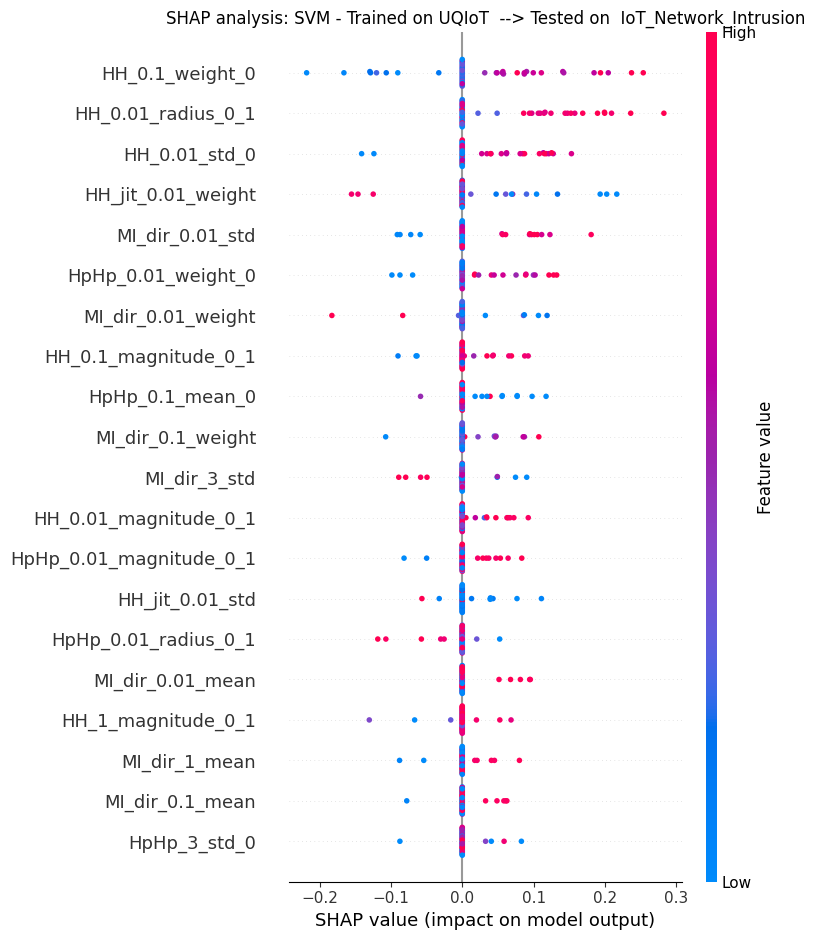

Computing SHAP values for DNN...


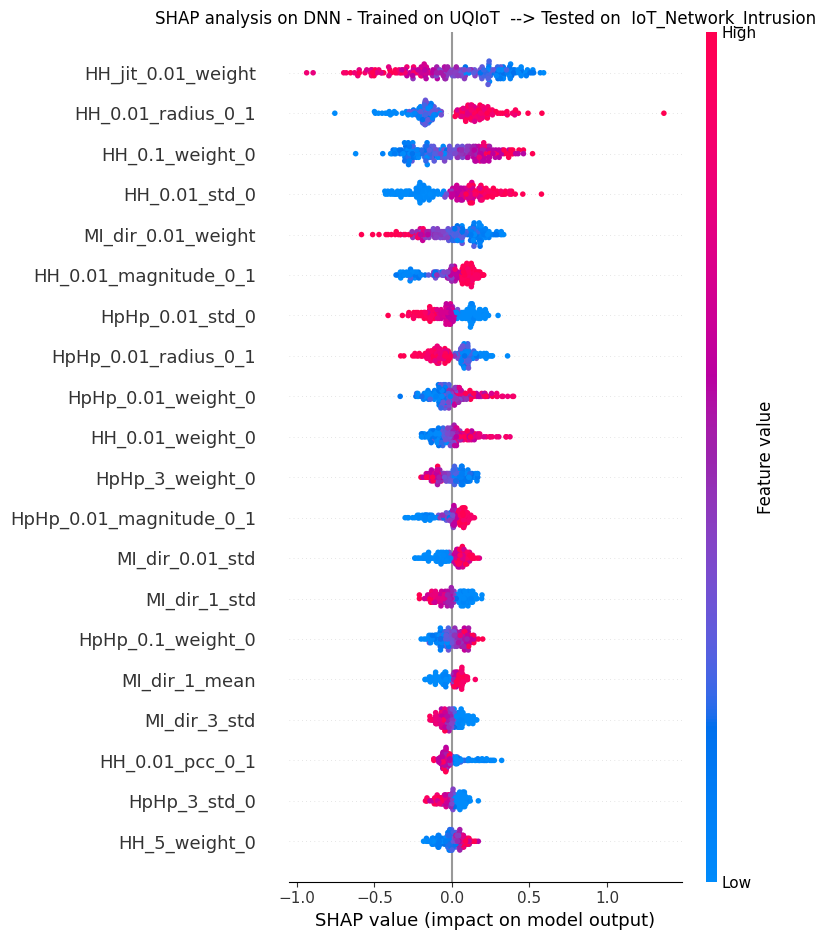


 Top 20 features across all 7 models are:

Top 10 - Decision Tree:
                Feature  Mean SHAP
     HH_0.01_radius_0_1   0.193639
        HpHp_0.01_std_0   0.149629
     HH_jit_0.01_weight   0.070869
        HH_jit_0.01_std   0.065174
      HpHp_0.1_weight_0   0.057749
         HH_0.1_pcc_0_1   0.036284
   HH_0.1_magnitude_0_1   0.035997
        HH_1_radius_0_1   0.034158
       MI_dir_0.01_mean   0.032944
HpHp_0.01_magnitude_0_1   0.032596

Top 10 - Random Forest:
              Feature  Mean SHAP
   HH_0.01_radius_0_1   0.053244
      MI_dir_0.01_std   0.034158
      HH_jit_0.01_std   0.029500
        HH_0.01_std_0   0.029375
       HH_0.1_pcc_0_1   0.021704
     HH_jit_0.01_mean   0.020946
   HH_jit_0.01_weight   0.016934
      HH_jit_0.1_mean   0.013152
HH_0.01_magnitude_0_1   0.012196
         HH_0.1_std_0   0.012125

Top 10 - XGBoost:
           Feature  Mean SHAP
HH_0.01_radius_0_1   1.859751
MI_dir_0.01_weight   0.692689
  HH_0.01_weight_0   0.557892
  HH_jit_0.01_mean  

In [19]:
all_cross_dataset_shap={}

for combination, (models, X_train_df, X_test_df) in trained_combinations.items():
    train_name, test_name=combination.split("->")
    print(f"\nSHAP Combination: {combination}")

    shap_values=shap_for_combination(models=models, X_train_df=X_train_df, X_test_df=X_test_df, train_name=train_name, test_name=test_name)
    all_cross_dataset_shap[combination]=shap_values

print("\nALL cross-dataset SHAP are calculated")